# Bitcoin Kursvorhersage mit Machine Learning  
**Autor:** Mostafa Adlan – HTW Berlin  

In diesem Notebook untersuche ich, ob sich tägliche Kursbewegungen von Bitcoin (Up/Down) mithilfe von Machine-Learning-Modellen vorhersagen lassen.  
Dazu verwende ich verschiedene Einflussfaktoren wie Schlusskurs, Volumen und einfache technische Indikatoren (gleitende Durchschnitte, RSI, Volatilität).


## 1. Setup und verwendete Bibliotheken


In [154]:
# 1. Setup & Imports
# ==============================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Technical Indicators
import ta

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, balanced_accuracy_score

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import Input
from tensorflow.keras.metrics import AUC

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [155]:
# Project paths
PROJECT_ROOT = Path.cwd().parent  # notebooks/
DATA_PATH = PROJECT_ROOT / "data" / "btc_15m_data_2018_to_2025.csv"
FIG_DIR = PROJECT_ROOT / "thesis_figures"
FIG_DIR.mkdir(exist_ok=True)

def savefig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)


## 2. Data Loading (15-minute CSV)


In [156]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV not found at: {DATA_PATH}\n"
        "Put btc_15m_data_2018_to_2025.csv inside the data/ folder."
    )

print("Using file:", DATA_PATH, "| size (MB):", round(DATA_PATH.stat().st_size / (1024**2), 2))

# Try header-based read first
try:
    df_15m = pd.read_csv(
        DATA_PATH,
        parse_dates=["Open time"],
        index_col="Open time"
    )
except Exception as e:
    print("Header read failed, trying no-header fallback. Error:", e)
    cols = [
        "Open time","Open","High","Low","Close","Volume",
        "Close time","Quote asset volume","Number of trades",
        "Taker buy base asset volume","Taker buy quote asset volume","Ignore"
    ]
    df_15m = pd.read_csv(DATA_PATH, header=None, names=cols)
    df_15m["Open time"] = pd.to_datetime(df_15m["Open time"], errors="coerce")
    df_15m = df_15m.dropna(subset=["Open time"]).set_index("Open time")

# Clean + keep OHLCV
df_15m = df_15m.sort_index()
df_15m = df_15m[~df_15m.index.duplicated(keep="last")]
df_15m = df_15m[[c for c in ["Open","High","Low","Close","Volume"] if c in df_15m.columns]].copy()

for c in df_15m.columns:
    df_15m[c] = pd.to_numeric(df_15m[c], errors="coerce")

df_15m = df_15m.dropna()

# Filter years
df_15m = df_15m[(df_15m.index.year >= 2019) & (df_15m.index.year <= 2024)]

print("15m range:", df_15m.index.min(), "->", df_15m.index.max())
print("15m shape:", df_15m.shape)

df_15m.head()


Using file: /Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/data/btc_15m_data_2018_to_2025.csv | size (MB): 40.76
15m range: 2019-01-01 00:00:00 -> 2024-12-31 23:45:00
15m shape: (210162, 5)


,Open,High,Low,Close,Volume
Open time,,,,,
2019-01-01 00:00:00,3701.23,3703.72,3689.88,3697.31,190.974095
2019-01-01 00:15:00,3697.91,3698.75,3690.56,3694.20,131.742721
2019-01-01 00:30:00,3693.96,3705.00,3693.00,3702.39,171.877714
2019-01-01 00:45:00,3702.05,3713.00,3695.02,3700.31,191.772890
2019-01-01 01:00:00,3700.20,3702.73,3691.22,3701.03,139.872706


In [157]:
# Utility: Simple backtest (Long/Cash)

def backtest_simple(signal: pd.Series, rets: pd.Series, fee: float = 0.0):
    """
    signal: 1=Long, 0=Cash.
    rets: next-period returns aligned to signal index.
    fee: proportional cost per trade (entry/exit).
    """
    signal = signal.astype(int)
    trades = signal.diff().abs().fillna(0)
    strat = signal * rets - trades * fee
    equity = (1 + strat).cumprod()
    bh = (1 + rets).cumprod()
    return equity, bh, strat


In [158]:
# Ensure numeric columns are numeric (CSV sometimes loads them as strings)
for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in df_15m.columns:
        df_15m[col] = pd.to_numeric(df_15m[col], errors="coerce")

# Drop rows that became NaN after coercion
df_15m = df_15m.dropna(subset=["Close"])


In [159]:
# Ensure numeric types for OHLCV
for col in ["Open", "High", "Low", "Close", "Volume"]:
    df_15m[col] = pd.to_numeric(df_15m[col], errors="coerce")

# Drop rows where conversion failed
df_15m = df_15m.dropna(subset=["Close", "Volume"])


#  3) Daily Data (Resample / Prepare)



In [160]:
df_daily_ds = (
    df_15m
    .resample("1D")
    .agg({
        "Close": "last",
        "Volume": "sum"
    })
    .loc["2019-01-01":"2024-12-31"]
    .dropna()
)

print(
    "df_daily_ds:",
    df_daily_ds.index.min(),
    "->",
    df_daily_ds.index.max(),
    df_daily_ds.shape
)


df_daily_ds: 2019-01-01 00:00:00 -> 2024-12-31 00:00:00 (2192, 2)


In [161]:
print("Index min/max:", df_15m.index.min(), "->", df_15m.index.max())
print("Median delta:", df_15m.index.to_series().diff().median())
print("Shape:", df_15m.shape)


Index min/max: 2019-01-01 00:00:00 -> 2024-12-31 23:45:00
Median delta: 0 days 00:15:00
Shape: (210162, 5)


#  3) Feature Engineering




In [162]:
# 3.1 Features (15m): MA, EMA, RSI, Returns, Volatility, MACD, BB width, ATR

df_15m_feat = df_15m.copy()

# 1) Returns 
df_15m_feat["Return"] = df_15m_feat["Close"].pct_change()

# 2) Moving Averages (SMA)
df_15m_feat["MA5"]  = df_15m_feat["Close"].rolling(5).mean()
df_15m_feat["MA10"] = df_15m_feat["Close"].rolling(10).mean()

# 3) EMA 
df_15m_feat["EMA10"] = df_15m_feat["Close"].ewm(span=10, adjust=False).mean()
df_15m_feat["EMA30"] = df_15m_feat["Close"].ewm(span=30, adjust=False).mean()

# 4) RSI
df_15m_feat["RSI14"] = ta.momentum.RSIIndicator(close=df_15m_feat["Close"], window=14).rsi()

# 5) Volatility
df_15m_feat["Volatility7"] = df_15m_feat["Return"].rolling(7).std()

# 6) MACD
macd = ta.trend.MACD(close=df_15m_feat["Close"])
df_15m_feat["MACD"] = macd.macd()
df_15m_feat["MACD_signal"] = macd.macd_signal()

# 7) Bollinger Bands Width 
bb = ta.volatility.BollingerBands(close=df_15m_feat["Close"], window=20, window_dev=2)
df_15m_feat["BB_width"] = (bb.bollinger_hband() - bb.bollinger_lband()) / df_15m_feat["Close"]

# 8) ATR 
atr = ta.volatility.AverageTrueRange(
    high=df_15m_feat["High"], low=df_15m_feat["Low"], close=df_15m_feat["Close"], window=14
)
df_15m_feat["ATR14"] = atr.average_true_range()

df_15m_feat = df_15m_feat.dropna()

df_15m_feat.head(), df_15m_feat.shape


(                        Open     High      Low    Close      Volume    Return  \
 Open time                                                                       
 2019-01-01 08:15:00  3710.62  3729.28  3710.07  3727.79  301.187980  0.004630   
 2019-01-01 08:30:00  3727.11  3731.19  3717.64  3722.00  232.390476 -0.001553   
 2019-01-01 08:45:00  3721.33  3727.32  3714.50  3716.70  219.885156 -0.001424   
 2019-01-01 09:00:00  3716.98  3719.99  3708.30  3709.88  181.548091 -0.001835   
 2019-01-01 09:15:00  3711.66  3719.99  3709.86  3713.28  206.371995  0.000916   
 
                           MA5      MA10        EMA10        EMA30      RSI14  \
 Open time                                                                      
 2019-01-01 08:15:00  3714.492  3709.339  3710.760921  3703.300335  69.533374   
 2019-01-01 08:30:00  3716.640  3710.779  3712.804390  3704.506765  63.520806   
 2019-01-01 08:45:00  3718.186  3711.965  3713.512683  3705.293425  58.531519   
 2019-01-01 09:00:0

In [163]:
# 3.2 Daily - Feature Engineering + Target (no ATR because no High/Low)

df_ds = df_daily_ds.copy()

# Returns
df_ds["Return"] = df_ds["Close"].pct_change()

# SMA
df_ds["MA5"]  = df_ds["Close"].rolling(5).mean()
df_ds["MA10"] = df_ds["Close"].rolling(10).mean()

# EMA
df_ds["EMA10"] = df_ds["Close"].ewm(span=10, adjust=False).mean()
df_ds["EMA30"] = df_ds["Close"].ewm(span=30, adjust=False).mean()

# RSI
df_ds["RSI14"] = ta.momentum.RSIIndicator(close=df_ds["Close"], window=14).rsi()

# Volatility
df_ds["Volatility7D"] = df_ds["Return"].rolling(7).std()

# MACD
macd_d = ta.trend.MACD(close=df_ds["Close"])
df_ds["MACD"] = macd_d.macd()
df_ds["MACD_signal"] = macd_d.macd_signal()

# Bollinger width
bb_d = ta.volatility.BollingerBands(close=df_ds["Close"], window=20, window_dev=2)
df_ds["BB_width"] = (bb_d.bollinger_hband() - bb_d.bollinger_lband()) / df_ds["Close"]

# Target (next return)
df_ds["NextReturn"] = df_ds["Close"].shift(-1) / df_ds["Close"] - 1
df_ds["Target"] = (df_ds["NextReturn"] > 0).astype(int)

df_ds = df_ds.dropna()

features_ds = [
    "Close","Volume","Return","MA5","MA10","EMA10","EMA30",
    "RSI14","Volatility7D","MACD","MACD_signal","BB_width"
]

X_ds = df_ds[features_ds].copy()
y_ds = df_ds["Target"].copy()

print("df_ds shape:", df_ds.shape)
print("Period:", df_ds.index.min(), "->", df_ds.index.max())
print("Target distribution:\n", y_ds.value_counts())


df_ds shape: (2158, 14)
Period: 2019-02-03 00:00:00 -> 2024-12-30 00:00:00
Target distribution:
 Target
1    1112
0    1046
Name: count, dtype: int64


In [164]:
# 3.2.1 Create daily data from 15m

df_15m_daily = df_15m.resample("1D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
})

# remove empty days
df_15m_daily = df_15m_daily.dropna()

print("df_15m_daily shape:", df_15m_daily.shape)
df_15m_daily.head()

df_15m_daily shape: (2192, 5)


,Open,High,Low,Close,Volume
Open time,,,,,
2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033
2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


In [165]:
# 3.3 Intraday-based daily features from 15m

df_intraday = df_15m.copy()

# Returns on 15m
df_intraday["ret_15m"] = df_intraday["Close"].pct_change()

# Features per day from 15m
daily_features = pd.DataFrame(index=df_15m_daily.index)

# Basic daily values
daily_features["Close"] = df_15m_daily["Close"]
daily_features["Volume"] = df_15m_daily["Volume"]

# Intraday volatility (std of 15m returns within each day)
daily_features["IntraVol"] = (
    df_intraday["ret_15m"]
    .groupby(df_intraday.index.date)
    .std()
    .values
)

# Intraday range
daily_features["IntraRange"] = (
    (df_15m_daily["High"] - df_15m_daily["Low"])
    / df_15m_daily["Close"]
).values

# Momentum feature
daily_features["DailyReturn"] = df_15m_daily["Close"].pct_change()

# Moving averages
daily_features["MA5"]  = daily_features["Close"].rolling(5).mean()
daily_features["MA10"] = daily_features["Close"].rolling(10).mean()

# RSI
daily_features["RSI14"] = ta.momentum.RSIIndicator(
    close=daily_features["Close"],
    window=14
).rsi()

# Drop NaNs
daily_features = daily_features.dropna()

print("daily_features shape:", daily_features.shape)
daily_features.head()

daily_features shape: (2179, 8)


,Close,Volume,IntraVol,IntraRange,DailyReturn,MA5,MA10,RSI14
Open time,,,,,,,,
2019-01-14,3626.09,35235.211215,0.003386,0.056493,0.042936,3574.644,3752.901,41.041783
2019-01-15,3553.06,34137.997459,0.002626,0.037095,-0.020140,3568.080,3731.111,37.350363
2019-01-16,3591.84,27480.179977,0.001779,0.028256,0.010915,3566.186,3691.535,40.415110
2019-01-17,3616.21,29755.440838,0.001592,0.028845,0.006785,3572.802,3655.611,42.324522
2019-01-18,3594.87,22713.446755,0.001230,0.015091,-0.005901,3596.414,3619.585,41.083014


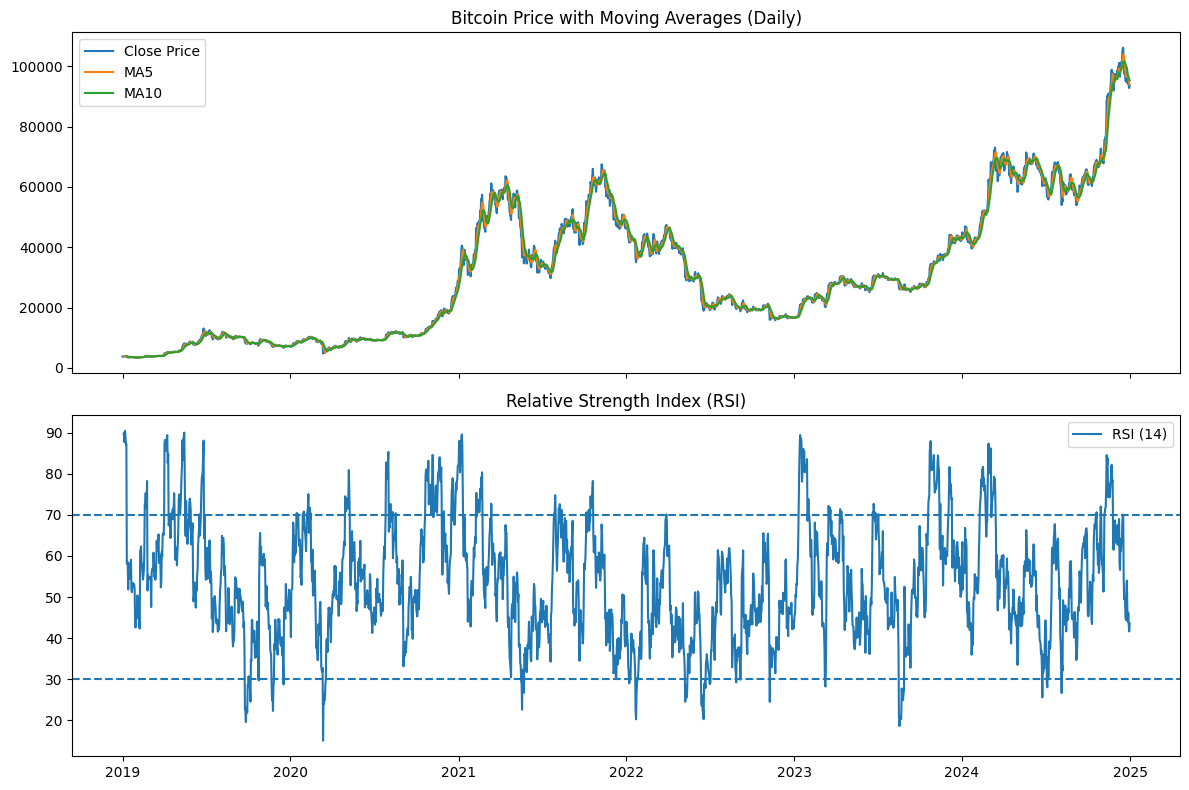

In [166]:
# 4. plotting daily price + indicators (Close, MA5, MA10, RSI)

df_daily = df_daily_ds.copy()

# --- 1) Detect column names ---
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

close_col = pick_col(df_daily, ["Close", "close", "CLOSE"])
if close_col is None:
    raise KeyError("I can't find the Close column. Available columns: " + str(df_daily.columns.tolist()))

ma5_col  = pick_col(df_daily, ["MA5", "ma5", "MA_5", "SMA5", "sma5"])
ma10_col = pick_col(df_daily, ["MA10", "ma10", "MA_10", "SMA10", "sma10"])
rsi_col  = pick_col(df_daily, ["RSI14", "rsi14", "RSI_14", "RSI", "rsi"])

# --- 2) Calculate MA if missing ---
if ma5_col is None:
    df_daily["MA5"] = df_daily[close_col].rolling(5).mean()
    ma5_col = "MA5"

if ma10_col is None:
    df_daily["MA10"] = df_daily[close_col].rolling(10).mean()
    ma10_col = "MA10"

# --- 3) Calculate RSI if missing ---
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss.replace(0, np.nan))
    return 100 - (100 / (1 + rs))

if rsi_col is None:
    df_daily["RSI14"] = rsi(df_daily[close_col], period=14)
    rsi_col = "RSI14"

# --- 4) Plot ---
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_daily.index, df_daily[close_col], label="Close Price")
ax[0].plot(df_daily.index, df_daily[ma5_col], label="MA5")
ax[0].plot(df_daily.index, df_daily[ma10_col], label="MA10")
ax[0].legend()
ax[0].set_title("Bitcoin Price with Moving Averages (Daily)")

ax[1].plot(df_daily.index, df_daily[rsi_col], label="RSI (14)")
ax[1].axhline(70, linestyle="--")
ax[1].axhline(30, linestyle="--")
ax[1].set_title("Relative Strength Index (RSI)")
ax[1].legend()

plt.tight_layout()
plt.savefig("thesis_figures/07_price_indicators_daily.png", dpi=200)
plt.show()


## 5) Target Variable Definition

This section defines the binary prediction target (Up/Down)
for daily and intraday datasets based on future price movements.


y_daily built: 2191
Class distribution:
 Close
1    1126
0    1065
Name: count, dtype: int64


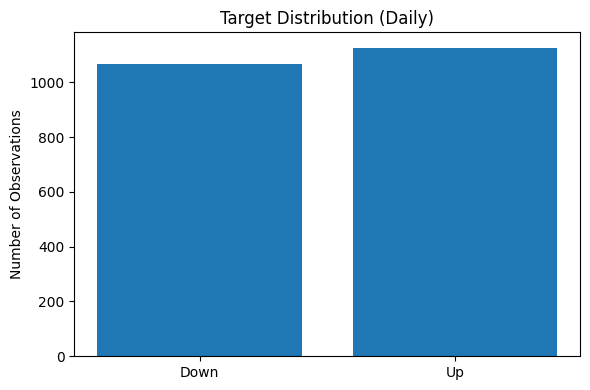

X_daily shape: (2191, 2)
y_daily length: 2191


In [167]:
# 5. Target distribution (Daily)
# --- choose the daily OHLCV dataframe ---
df_daily = df_15m_daily   # daily dataset (Open, High, Low, Close, Volume)

# --- build daily target: next-day direction (Up=1, Down=0) ---
y_daily = (df_daily["Close"].shift(-1) > df_daily["Close"]).astype(int)

# drop last label because it becomes NaN after shift
y_daily = y_daily.iloc[:-1]

print("y_daily built:", len(y_daily))
print("Class distribution:\n", y_daily.value_counts())

# --- create output folder if not exists ---
os.makedirs("thesis_figures", exist_ok=True)

# --- plot ---
target_counts = y_daily.value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Down", "Up"], target_counts.values)
plt.title("Target Distribution (Daily)")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.savefig("thesis_figures/06_target_distribution_daily.png", dpi=200)
plt.show()

# Align daily features with y_daily length (drop last row)
X_daily = df_daily_ds.iloc[:-1].copy()

print("X_daily shape:", X_daily.shape)
print("y_daily length:", len(y_daily))


In [168]:

# 5.2 Target (15m): Balanced target using TRAIN-only median threshold (NO leakage)

df_15m_feat["NextReturn"] = df_15m_feat["Close"].shift(-1) / df_15m_feat["Close"] - 1

df_15m_feat = df_15m_feat.dropna()

split_idx = int(len(df_15m_feat) * 0.7)

thr_train = df_15m_feat.iloc[:split_idx]["NextReturn"].median()

df_15m_feat["Target"] = (df_15m_feat["NextReturn"] > thr_train).astype(int)

print("Train-only median threshold:", thr_train)
print("Target distribution (full):\n", df_15m_feat["Target"].value_counts(normalize=True).round(3))
print("Target distribution (train):\n", df_15m_feat.iloc[:split_idx]["Target"].value_counts(normalize=True).round(3))
print("Target distribution (test):\n", df_15m_feat.iloc[split_idx:]["Target"].value_counts(normalize=True).round(3))


Train-only median threshold: 2.151279045703447e-05
Target distribution (full):
 Target
0    0.501
1    0.499
Name: proportion, dtype: float64
Target distribution (train):
 Target
0    0.5
1    0.5
Name: proportion, dtype: float64
Target distribution (test):
 Target
0    0.502
1    0.498
Name: proportion, dtype: float64


In [169]:
# 5.3 Train/Test Split (Daily) - Time-based + Scaling

split_idx = int(len(df_ds) * 0.7)

X_train_ds, X_test_ds = X_ds.iloc[:split_idx], X_ds.iloc[split_idx:]
y_train_ds, y_test_ds = y_ds.iloc[:split_idx], y_ds.iloc[split_idx:]

print("Train:", X_train_ds.shape, "Test:", X_test_ds.shape)
print("Train period:", X_train_ds.index.min(), "->", X_train_ds.index.max())
print("Test  period:", X_test_ds.index.min(), "->", X_test_ds.index.max())

from sklearn.preprocessing import StandardScaler

scaler_ds = StandardScaler()
X_train_ds_scaled = scaler_ds.fit_transform(X_train_ds)
X_test_ds_scaled  = scaler_ds.transform(X_test_ds)


Train: (1510, 12) Test: (648, 12)
Train period: 2019-02-03 00:00:00 -> 2023-03-23 00:00:00
Test  period: 2023-03-24 00:00:00 -> 2024-12-30 00:00:00


# 6) Train / Test Split


In [170]:
# 6.2 Train/Test Split (15m)

# Target (15m): next candle direction
y_15m = (df_15m["Close"].shift(-1) > df_15m["Close"]).astype(int)

# Features (use same indicators already computed)
X_15m = df_15m[["Close", "Volume"]].copy()

# Remove last row (NaN target)
X_15m = X_15m.iloc[:-1]
y_15m = y_15m.iloc[:-1]

# Time-based split (80/20)
split_idx = int(len(X_15m) * 0.8)

X_train_15m = X_15m.iloc[:split_idx]
X_test_15m  = X_15m.iloc[split_idx:]

y_train_15m = y_15m.iloc[:split_idx]
y_test_15m  = y_15m.iloc[split_idx:]

print("15m split done:")
print("Train:", X_train_15m.shape)
print("Test :", X_test_15m.shape)

15m split done:
Train: (168128, 2)
Test : (42033, 2)


In [171]:
# 6.2 Train/Test Split (15m) - Time-based (UPDATED features)

features_15m = [
    "Close","Volume","Return","MA5","MA10","EMA10","EMA30",
    "RSI14","Volatility7","MACD","MACD_signal","BB_width","ATR14"
]

X_15m = df_15m_feat[features_15m].copy()
y_15m = df_15m_feat["Target"].copy()


X_train_15m, X_test_15m = X_15m.iloc[:split_idx], X_15m.iloc[split_idx:]
y_train_15m, y_test_15m = y_15m.iloc[:split_idx], y_15m.iloc[split_idx:]

print("Train:", X_train_15m.shape, "Test:", X_test_15m.shape)
print("Train period:", X_train_15m.index.min(), "->", X_train_15m.index.max())
print("Test  period:", X_test_15m.index.min(), "->", X_test_15m.index.max())

from sklearn.preprocessing import StandardScaler

scaler_15m = StandardScaler()
X_train_15m_scaled = scaler_15m.fit_transform(X_train_15m)
X_test_15m_scaled  = scaler_15m.transform(X_test_15m)
print("Train size:", len(X_train_15m))
print("Test size :", len(X_test_15m))
print("Split ratio:", len(X_train_15m) / (len(X_train_15m) + len(X_test_15m)))



Train: (168128, 13) Test: (42000, 13)
Train period: 2019-01-01 08:15:00 -> 2023-10-21 11:30:00
Test  period: 2023-10-21 11:45:00 -> 2024-12-31 23:30:00
Train size: 168128
Test size : 42000
Split ratio: 0.8001218305033123


In [172]:
# 6.1 Baselines (Daily & 15m) - Majority / Random / Persistence


def baseline_majority(y_train, y_test):
    maj = int(y_train.mode().iloc[0])
    y_pred = np.full(len(y_test), maj, dtype=int)
    return y_pred

def baseline_random(y_train, y_test, seed=42):
    rng = np.random.RandomState(seed)
    p_up = float(y_train.mean())  # P(class=1) from TRAIN
    y_pred = rng.binomial(1, p_up, size=len(y_test)).astype(int)
    return y_pred

def baseline_persistence(y_train, y_test):
    # Predict y_t = y_{t-1}; first test prediction uses last train label
    prev = int(y_train.iloc[-1])
    y_pred = np.empty(len(y_test), dtype=int)
    if len(y_test) == 0:
        return y_pred
    y_pred[0] = prev
    if len(y_test) > 1:
        y_pred[1:] = np.asarray(y_test.iloc[:-1], dtype=int)
    return y_pred

def eval_baseline(y_test, y_pred):
    y_test = np.asarray(y_test, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)

    # For ROC-AUC we can use class labels as "scores" for baselines
    # If only one class is predicted, roc_auc_score may error -> set to 0.5
    try:
        auc = roc_auc_score(y_test, y_pred)
    except:
        auc = 0.5

    return acc, bacc, auc

def run_all_baselines(name, y_train, y_test):
    baselines = {
        "Majority"   : baseline_majority(y_train, y_test),
        "Random"     : baseline_random(y_train, y_test, seed=42),
        "Persistence": baseline_persistence(y_train, y_test),
    }

    print(f"\n=== Baselines ({name}) ===")
    for bname, y_pred in baselines.items():
        acc, bacc, auc = eval_baseline(y_test, y_pred)
        print(f"{bname:<11} | Accuracy={acc:.4f} | Bal.Acc={bacc:.4f} | ROC-AUC={auc:.4f}")

# --- Run for BOTH datasets (must exist in notebook) ---
run_all_baselines("Daily", y_train_ds, y_test_ds)
run_all_baselines("15m",   y_train_15m, y_test_15m)



=== Baselines (Daily) ===
Majority    | Accuracy=0.5170 | Bal.Acc=0.5000 | ROC-AUC=0.5000
Random      | Accuracy=0.4877 | Bal.Acc=0.4873 | ROC-AUC=0.4873
Persistence | Accuracy=0.4552 | Bal.Acc=0.4547 | ROC-AUC=0.4547

=== Baselines (15m) ===
Majority    | Accuracy=0.4995 | Bal.Acc=0.5000 | ROC-AUC=0.5000
Random      | Accuracy=0.5020 | Bal.Acc=0.5020 | ROC-AUC=0.5020
Persistence | Accuracy=0.4782 | Bal.Acc=0.4782 | ROC-AUC=0.4782


/Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


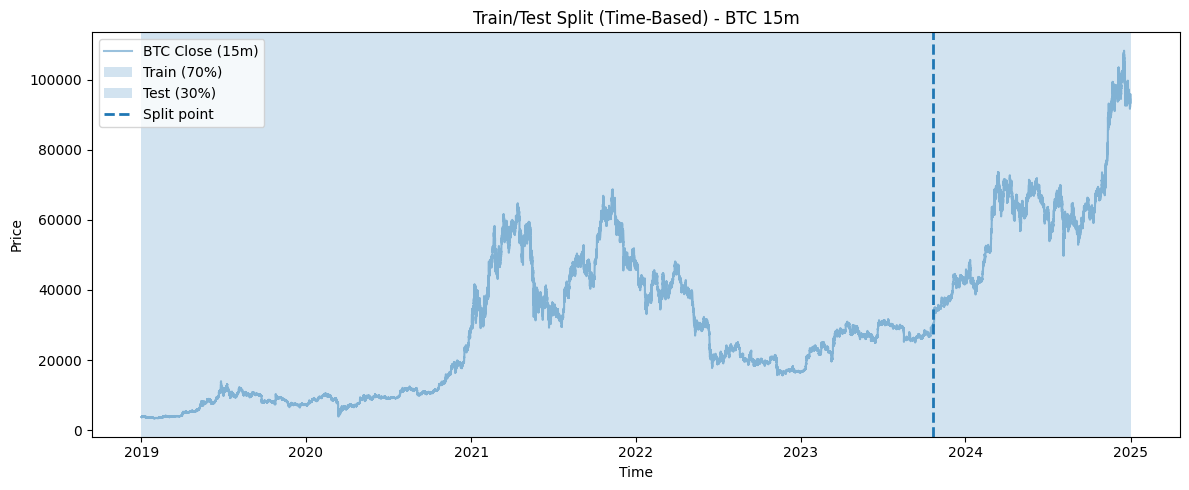

In [173]:
# 6.3 Figure: Train/Test Split (15m) - Time-based


split_time = df_15m_feat.index[split_idx]

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_15m_feat.index, df_15m_feat["Close"], alpha=0.45, label="BTC Close (15m)")

ax.axvspan(df_15m_feat.index[0], split_time, alpha=0.20, label="Train (70%)")
ax.axvspan(split_time, df_15m_feat.index[-1], alpha=0.20, label="Test (30%)")

ax.axvline(split_time, linestyle="--", linewidth=2, label="Split point")

ax.set_title("Train/Test Split (Time-Based) - BTC 15m")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()


In [174]:

# 6.4 Build Daily dataset from 15m (Aggregation)
# Target horizon will be NEXT DAY (same as daily)

df_15m_local = df_15m.copy()

df_15m_local = df_15m_local.sort_index()

# Daily aggregation from 15m
df_15m_daily = df_15m_local.resample("1D").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
    "Volume": "sum"
}).dropna()

print("df_15m_daily shape:", df_15m_daily.shape)
print("Period:", df_15m_daily.index.min(), "->", df_15m_daily.index.max())

df_15m_daily.head()


df_15m_daily shape: (2192, 5)
Period: 2019-01-01 00:00:00 -> 2024-12-31 00:00:00


,Open,High,Low,Close,Volume
Open time,,,,,
2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033
2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


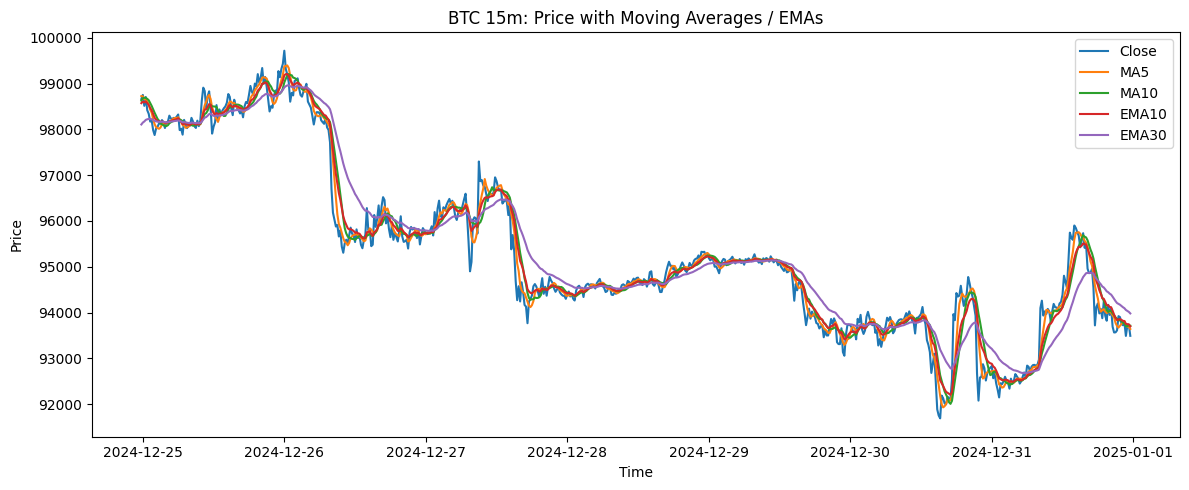

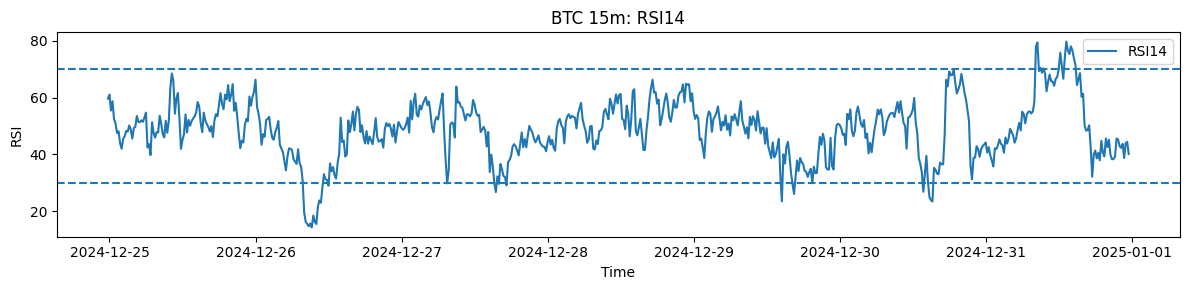

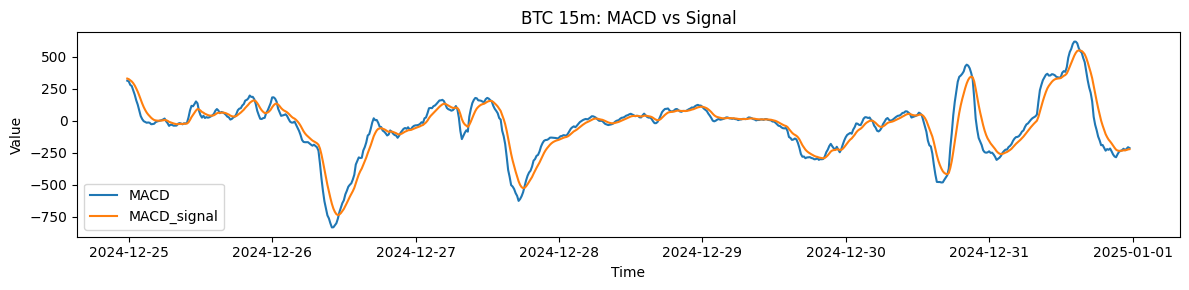

In [175]:
# 6.5  Chart: Example Indicators (15m)


sample = df_15m_feat.tail(7*24*4).copy()   # 7 days * 24h * 4 (15m)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample.index, sample["Close"], label="Close")
ax.plot(sample.index, sample["MA5"], label="MA5")
ax.plot(sample.index, sample["MA10"], label="MA10")
ax.plot(sample.index, sample["EMA10"], label="EMA10")
ax.plot(sample.index, sample["EMA30"], label="EMA30")
ax.set_title("BTC 15m: Price with Moving Averages / EMAs")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(sample.index, sample["RSI14"], label="RSI14")
ax.axhline(70, linestyle="--")
ax.axhline(30, linestyle="--")
ax.set_title("BTC 15m: RSI14")
ax.set_xlabel("Time")
ax.set_ylabel("RSI")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(sample.index, sample["MACD"], label="MACD")
ax.plot(sample.index, sample["MACD_signal"], label="MACD_signal")
ax.set_title("BTC 15m: MACD vs Signal")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()


In [176]:


# 6.7 Daily features
X = X_ds.copy()
y = y_ds.copy()

def walk_forward_expanding(X, y, splits=5, start_frac=0.5):
    n = len(X)
    train_end = int(n * start_frac)
    step = (n - train_end) // splits

    results = []

    for i in range(splits):
        test_start = train_end
        test_end = test_start + step

        if test_end > n:
            break

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]
        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        # Logistic
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ])
        lr.fit(X_train, y_train)
        prob_lr = lr.predict_proba(X_test)[:,1]
        pred_lr = (prob_lr >= 0.5).astype(int)

        # Random Forest
        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        )
        rf.fit(X_train, y_train)
        prob_rf = rf.predict_proba(X_test)[:,1]
        pred_rf = (prob_rf >= 0.5).astype(int)

        results.append({
            "split": i+1,
            "LR_acc": accuracy_score(y_test, pred_lr),
            "LR_auc": roc_auc_score(y_test, prob_lr),
            "RF_acc": accuracy_score(y_test, pred_rf),
            "RF_auc": roc_auc_score(y_test, prob_rf),
        })

        train_end = test_end

    return pd.DataFrame(results)

wf_daily = walk_forward_expanding(X, y, splits=5, start_frac=0.5)

wf_daily


,split,LR_acc,LR_auc,RF_acc,RF_auc
0,1,0.465116,0.472870,0.460465,0.469304
1,2,0.534884,0.508077,0.558140,0.597794
2,3,0.539535,0.559511,0.534884,0.531705
3,4,0.516279,0.606140,0.511628,0.578684
4,5,0.525581,0.485113,0.479070,0.495067


In [177]:
wf_daily.agg(["mean","std"])


,split,LR_acc,LR_auc,RF_acc,RF_auc
mean,3.000000,0.516279,0.526342,0.508837,0.534511
std,1.581139,0.029963,0.055589,0.039821,0.054249


In [178]:
# 6.8 Target: Next-Day Up/Down (same horizon as daily baseline)

df_intraday_daily = daily_features.copy()

df_intraday_daily["TargetNextDay"] = (df_intraday_daily["Close"].shift(-1) > df_intraday_daily["Close"]).astype(int)
df_intraday_daily = df_intraday_daily.dropna()

X_intra = df_intraday_daily.drop(columns=["TargetNextDay"])
y_intra = df_intraday_daily["TargetNextDay"]

print("Target distribution:\n", y_intra.value_counts())
df_intraday_daily.head()


Target distribution:
 TargetNextDay
1    1120
0    1059
Name: count, dtype: int64


,Close,Volume,IntraVol,IntraRange,DailyReturn,MA5,MA10,RSI14,TargetNextDay
Open time,,,,,,,,,
2019-01-14,3626.09,35235.211215,0.003386,0.056493,0.042936,3574.644,3752.901,41.041783,0
2019-01-15,3553.06,34137.997459,0.002626,0.037095,-0.020140,3568.080,3731.111,37.350363,1
2019-01-16,3591.84,27480.179977,0.001779,0.028256,0.010915,3566.186,3691.535,40.415110,1
2019-01-17,3616.21,29755.440838,0.001592,0.028845,0.006785,3572.802,3655.611,42.324522,0
2019-01-18,3594.87,22713.446755,0.001230,0.015091,-0.005901,3596.414,3619.585,41.083014,1


In [179]:
features_15m = [
    "Close","Volume","Return","MA5","MA10","EMA10","EMA30",
    "RSI14","Volatility7","MACD","MACD_signal","BB_width","ATR14"
]


In [180]:
# 6.9 Walk-forward


# استخدم نفس features و target
X = df_15m_feat[features_15m].copy()
y = df_15m_feat["Target"].copy()

def walk_forward_expanding(X, y, splits=5, start_frac=0.5):
    n = len(X)
    train_end = int(n * start_frac)
    step = (n - train_end) // splits

    results = []

    for i in range(splits):
        test_start = train_end
        test_end = test_start + step

        if test_end > n:
            break

        X_train = X.iloc[:train_end]
        y_train = y.iloc[:train_end]
        X_test = X.iloc[test_start:test_end]
        y_test = y.iloc[test_start:test_end]

        # Logistic
        lr = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ])
        lr.fit(X_train, y_train)
        prob_lr = lr.predict_proba(X_test)[:,1]
        pred_lr = (prob_lr >= 0.5).astype(int)

        # Random Forest
        rf = RandomForestClassifier(
            n_estimators=150,
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        )
        rf.fit(X_train, y_train)
        prob_rf = rf.predict_proba(X_test)[:,1]
        pred_rf = (prob_rf >= 0.5).astype(int)

        results.append({
            "split": i+1,
            "LR_acc": accuracy_score(y_test, pred_lr),
            "LR_auc": roc_auc_score(y_test, prob_lr),
            "RF_acc": accuracy_score(y_test, pred_rf),
            "RF_auc": roc_auc_score(y_test, prob_rf),
        })

        train_end = test_end  # expanding window

    return pd.DataFrame(results)

wf_15m = walk_forward_expanding(X, y, splits=5, start_frac=0.5)

wf_15m


,split,LR_acc,LR_auc,RF_acc,RF_auc
0,1,0.529507,0.536970,0.525890,0.533923
1,2,0.533552,0.554574,0.537598,0.559725
2,3,0.539787,0.553642,0.539787,0.555992
3,4,0.527413,0.548554,0.531411,0.547464
4,5,0.521512,0.537422,0.526366,0.535273


In [181]:
wf_15m.agg(["mean","std"])


,split,LR_acc,LR_auc,RF_acc,RF_auc
mean,3.000000,0.530354,0.546232,0.532210,0.546475
std,1.581139,0.006833,0.008563,0.006348,0.011728


Saved: /Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/thesis_figures/04_walkforward_accuracy.png


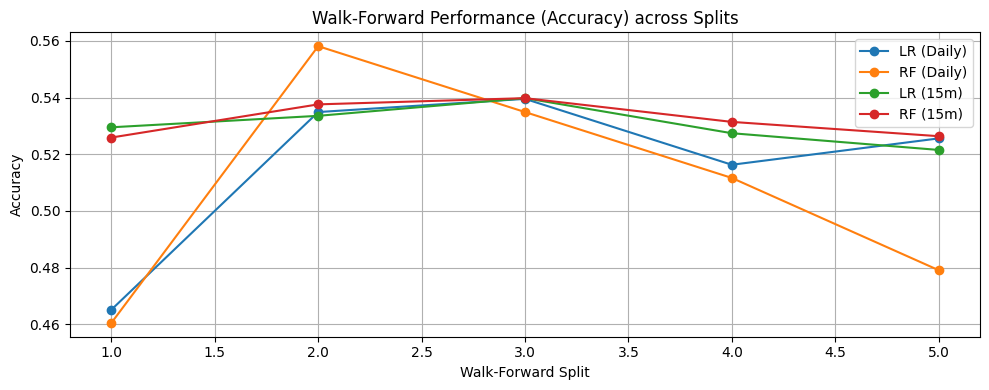

In [182]:

# 6.9b-- Plot Walk-Forward Accuracies ---
plt.figure(figsize=(10,4))

plt.plot(wf_daily["split"], wf_daily["LR_acc"], marker="o", label="LR (Daily)")
plt.plot(wf_daily["split"], wf_daily["RF_acc"], marker="o", label="RF (Daily)")

plt.plot(wf_15m["split"], wf_15m["LR_acc"], marker="o", label="LR (15m)")
plt.plot(wf_15m["split"], wf_15m["RF_acc"], marker="o", label="RF (15m)")

plt.xlabel("Walk-Forward Split")
plt.ylabel("Accuracy")
plt.title("Walk-Forward Performance (Accuracy) across Splits")
plt.grid(True)
plt.legend()

savefig("04_walkforward_accuracy.png")
plt.show()


In [183]:
print("df_15m_feat columns:", df_15m_feat.columns.tolist())
print("Shape:", df_15m_feat.shape)


df_15m_feat columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA5', 'MA10', 'EMA10', 'EMA30', 'RSI14', 'Volatility7', 'MACD', 'MACD_signal', 'BB_width', 'ATR14', 'NextReturn', 'Target']
Shape: (210128, 18)


In [184]:
X_train_ds.shape, X_test_ds.shape


((1510, 12), (648, 12))

In [185]:
# 6.9c Time-based split (no shuffle)

split_idx = int(len(df_intraday_daily) * 0.7)

X_train_intra, X_test_intra = X_intra.iloc[:split_idx], X_intra.iloc[split_idx:]
y_train_intra, y_test_intra = y_intra.iloc[:split_idx], y_intra.iloc[split_idx:]

print("Train:", X_train_intra.shape, "Test:", X_test_intra.shape)
print("Train period:", X_train_intra.index.min(), "->", X_train_intra.index.max())
print("Test  period:", X_test_intra.index.min(), "->", X_test_intra.index.max())


Train: (1525, 8) Test: (654, 8)
Train period: 2019-01-14 00:00:00 -> 2023-03-18 00:00:00
Test  period: 2023-03-19 00:00:00 -> 2024-12-31 00:00:00


## 7. Model Training and Evaluation




In [186]:
# 7.1 Train a simple Logistic Regression (Daily)

log_reg_ds = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_ds.fit(X_train_ds, y_train_ds)

y_pred_lr_ds = log_reg_ds.predict(X_test_ds)

print("Daily Logistic Regression trained ✅")


Daily Logistic Regression trained ✅


In [187]:
# 7.2 Logistic Regression (Daily)

log_reg_ds = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_ds.fit(X_train_ds, y_train_ds)
y_pred_lr_ds = log_reg_ds.predict(X_test_ds)

acc_lr_ds = accuracy_score(y_test_ds, y_pred_lr_ds)

y_prob_lr_ds = log_reg_ds.predict_proba(X_test_ds)[:, 1]

print("### Logistic Regression (Daily) ###")
print("Accuracy        :", round(accuracy_score(y_test_ds, y_pred_lr_ds), 4))
print("Balanced Acc    :", round(balanced_accuracy_score(y_test_ds, y_pred_lr_ds), 4))
print("ROC-AUC         :", round(roc_auc_score(y_test_ds, y_prob_lr_ds), 4))
print(classification_report(y_test_ds, y_pred_lr_ds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test_ds, y_pred_lr_ds))


### Logistic Regression (Daily) ###
Accuracy        : 0.5231
Balanced Acc    : 0.5292
ROC-AUC         : 0.5404
              precision    recall  f1-score   support

           0     0.5046    0.7061    0.5885       313
           1     0.5619    0.3522    0.4330       335

    accuracy                         0.5231       648
   macro avg     0.5332    0.5292    0.5108       648
weighted avg     0.5342    0.5231    0.5081       648

Confusion Matrix:
 [[221  92]
 [217 118]]


In [188]:

# 7.3 Random Forest (Daily)
print("\n### Baseline Models (Daily) ###")

# Majority baseline
majority_class_daily = y_train_ds.mode()[0]
y_pred_majority_daily = np.full_like(y_test_ds, majority_class_daily)

print("Majority baseline:")
print("Accuracy       :", accuracy_score(y_test_ds, y_pred_majority_daily))
print("Balanced Acc   :", balanced_accuracy_score(y_test_ds, y_pred_majority_daily))

# Random baseline
np.random.seed(42)
y_pred_random_daily = np.random.randint(0, 2, size=len(y_test_ds))

print("\nRandom baseline:")
print("Accuracy       :", accuracy_score(y_test_ds, y_pred_random_daily))
print("Balanced Acc   :", balanced_accuracy_score(y_test_ds, y_pred_random_daily))

# Persistence baseline (predict previous direction)
y_pred_persistence_daily = np.roll(y_test_ds.values, 1)
y_pred_persistence_daily[0] = 0

print("\nPersistence baseline:")
print("Accuracy       :", accuracy_score(y_test_ds, y_pred_persistence_daily))
print("Balanced Acc   :", balanced_accuracy_score(y_test_ds, y_pred_persistence_daily))



### Baseline Models (Daily) ###
Majority baseline:
Accuracy       : 0.5169753086419753
Balanced Acc   : 0.5

Random baseline:
Accuracy       : 0.4876543209876543
Balanced Acc   : 0.48695818034428495

Persistence baseline:
Accuracy       : 0.45524691358024694
Balanced Acc   : 0.4546707357779791


In [189]:
# 7.4 Bootstrap CI for ROC-AUC (Daily Logistic Regression)

print("\n### Bootstrap CI for ROC-AUC (Logistic Daily) ###")

y_true = y_test_ds.values
y_prob = y_prob_lr_ds

n_bootstraps = 1000
rng = np.random.RandomState(42)
boot_scores = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_true), len(y_true))
    if len(np.unique(y_true[indices])) < 2:
        continue
    score = roc_auc_score(y_true[indices], y_prob[indices])
    boot_scores.append(score)

boot_scores = np.array(boot_scores)

lower = np.percentile(boot_scores, 2.5)
upper = np.percentile(boot_scores, 97.5)
mean_auc = np.mean(boot_scores)

print(f"Mean AUC       : {mean_auc:.4f}")
print(f"95% CI         : [{lower:.4f}, {upper:.4f}]")
print(f"Original AUC   : {roc_auc_score(y_true, y_prob):.4f}")



### Bootstrap CI for ROC-AUC (Logistic Daily) ###
Mean AUC       : 0.5403
95% CI         : [0.4928, 0.5860]
Original AUC   : 0.5404


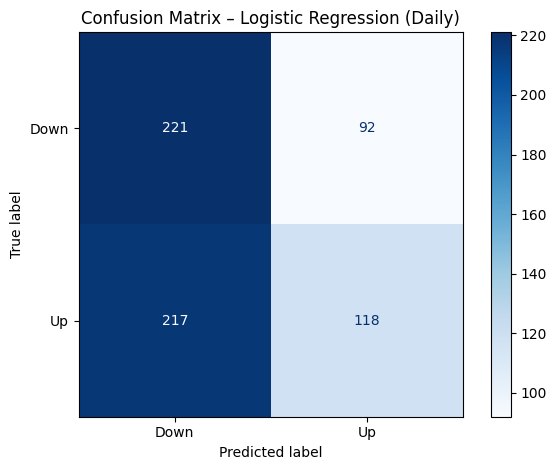

In [190]:
# 7.5 Confusion Matrix (Daily Logistic Regression)

cm_lr = confusion_matrix(y_test_ds, y_pred_lr_ds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Down", "Up"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression (Daily)")

plt.tight_layout()
plt.savefig("thesis_figures/04_confusion_matrix_lr_daily.png", dpi=200)
plt.show()


In [191]:
# 7.6 Random Forest (Daily)

rf_ds = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

rf_ds.fit(X_train_ds, y_train_ds)
y_pred_rf_ds = rf_ds.predict(X_test_ds)

acc_rf_ds = accuracy_score(y_test_ds, y_pred_rf_ds)

y_prob_rf_ds = rf_ds.predict_proba(X_test_ds)[:, 1]

print("### Random Forest (Daily) ###")
print("Accuracy        :", round(accuracy_score(y_test_ds, y_pred_rf_ds), 4))
print("Balanced Acc    :", round(balanced_accuracy_score(y_test_ds, y_pred_rf_ds), 4))
print("ROC-AUC         :", round(roc_auc_score(y_test_ds, y_prob_rf_ds), 4))
print(classification_report(y_test_ds, y_pred_rf_ds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test_ds, y_pred_rf_ds))


### Random Forest (Daily) ###
Accuracy        : 0.5093
Balanced Acc    : 0.5221
ROC-AUC         : 0.5317
              precision    recall  f1-score   support

           0     0.4956    0.9010    0.6395       313
           1     0.6076    0.1433    0.2319       335

    accuracy                         0.5093       648
   macro avg     0.5516    0.5221    0.4357       648
weighted avg     0.5535    0.5093    0.4288       648

Confusion Matrix:
 [[282  31]
 [287  48]]


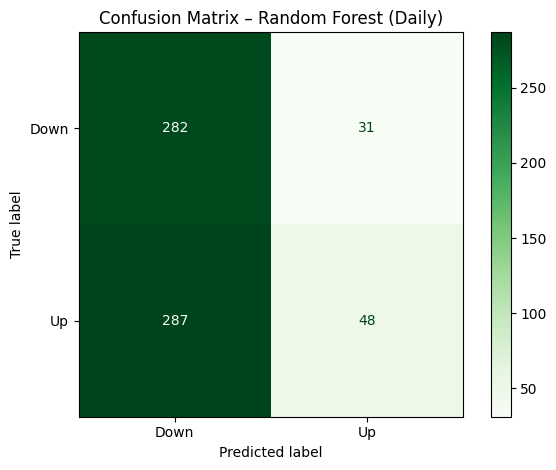

In [192]:

# 7.7 Confusion Matrix (Daily Random Forest)
cm_rf = confusion_matrix(y_test_ds, y_pred_rf_ds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Down", "Up"]
)

disp.plot(cmap="Greens")
plt.title("Confusion Matrix – Random Forest (Daily)")
plt.tight_layout()
plt.savefig("thesis_figures/04_confusion_matrix_lr_daily.png", dpi=200)
plt.show()

In [193]:
# 7.8 Feature Importance (Daily Random Forest)

# -----------------------------
# 1) Define daily features + target (aligned)
# -----------------------------
X_daily = df_daily_ds.copy()          # features: Close + Volume
y_daily = y_daily.copy()              # target: 0/1 (Down/Up)

# align lengths (drop last row in X to match y_daily that has last removed)
X_daily = X_daily.iloc[:len(y_daily)].copy()

print("X_daily shape:", X_daily.shape)
print("y_daily length:", len(y_daily))

# -----------------------------
# 2) Time-based split index (70/30)
# -----------------------------
split_idx = int(len(X_daily) * 0.7)

X_train_raw = X_daily.iloc[:split_idx]
X_test_raw  = X_daily.iloc[split_idx:]

y_train = y_daily.iloc[:split_idx]
y_test  = y_daily.iloc[split_idx:]

# -----------------------------
# 3) Fit scaler on TRAIN only (no leakage), transform all
# -----------------------------
scaler = StandardScaler()
scaler.fit(X_train_raw)

X_scaled_all = scaler.transform(X_daily)

print("split_idx:", split_idx)


X_daily shape: (2191, 2)
y_daily length: 2191
split_idx: 1533


In [194]:
# -----------------------------
# 1) Create sequences over full timeline (so test doesn't lose first days)
# -----------------------------
seq_len_daily = 14  # Bachelor-level: 2 weeks history

def make_sequences_full(X_scaled, y_series, seq_len):
    Xs, ys, pos = [], [], []
    for i in range(seq_len, len(X_scaled)):
        Xs.append(X_scaled[i-seq_len:i])
        ys.append(y_series.iloc[i])
        pos.append(i)
    return np.array(Xs), np.array(ys), np.array(pos)

X_seq_all, y_seq_all, pos_all = make_sequences_full(X_scaled_all, y_daily, seq_len_daily)

# Split sequences by time (based on label position)
train_mask = pos_all < split_idx
test_mask  = pos_all >= split_idx

X_train_seq = X_seq_all[train_mask]
y_train_seq = y_seq_all[train_mask]

X_test_seq  = X_seq_all[test_mask]
y_test_seq  = y_seq_all[test_mask]

print("Daily LSTM sequences -> Train:", X_train_seq.shape, "Test:", X_test_seq.shape)

# -----------------------------
# 2) Build validation from last 20% of train (time-consistent)
# -----------------------------
val_size = int(len(X_train_seq) * 0.2)

X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]

X_tr  = X_train_seq[:-val_size]
y_tr  = y_train_seq[:-val_size]

print("Final Train:", X_tr.shape, "Val:", X_val.shape)

# -----------------------------
# 3) Build + Train LSTM (simple and Bachelor-level)
# -----------------------------
model_daily = Sequential([
    LSTM(32, input_shape=(X_tr.shape[1], X_tr.shape[2])),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model_daily.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_daily = model_daily.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    shuffle=False,          # IMPORTANT for time series
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 4) Evaluate
# -----------------------------
y_prob = model_daily.predict(X_test_seq).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc_lstm_ds = accuracy_score(y_test_seq, y_pred)

print("\n### LSTM (Daily) ###")
print("Accuracy:", round(acc_lstm_ds, 4))
print(classification_report(y_test_seq, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_seq, y_pred))


Daily LSTM sequences -> Train: (1519, 14, 2) Test: (658, 14, 2)
Final Train: (1216, 14, 2) Val: (303, 14, 2)


/Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5444 - loss: 0.6928 - val_accuracy: 0.5215 - val_loss: 0.6892
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5271 - loss: 0.6919 - val_accuracy: 0.5281 - val_loss: 0.6890
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5230 - loss: 0.6916 - val_accuracy: 0.5413 - val_loss: 0.6893
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5247 - loss: 0.6910 - val_accuracy: 0.5413 - val_loss: 0.6895
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5370 - loss: 0.6915 - val_accuracy: 0.5479 - val_loss: 0.6899
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5337 - loss: 0.6912 - val_accuracy: 0.5182 - val_loss: 0.6905
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5132 - loss: 0.6933 - val_accuracy: 0.5083 - val_loss: 0.6913
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

### LSTM (Daily) ###
Accuracy: 0.4954
              precision    recall

In [195]:
results_daily = pd.DataFrame({
    "Timeframe": ["Daily", "Daily", "Daily"],
    "Model": ["Logistic Regression", "Random Forest", "LSTM"],
    "Accuracy": [acc_lr_ds, acc_rf_ds, acc_lstm_ds]
})
results_daily


,Timeframe,Model,Accuracy
0,Daily,Logistic Regression,0.523148
1,Daily,Random Forest,0.509259
2,Daily,LSTM,0.495441


In [196]:
# 7.9 LSTM (Daily) - Sequence Modeling (CLEAN + no leakage + with AUC)



# ---------------------------------------------------------
# 0) Settings
# ---------------------------------------------------------
seq_len_daily = 30  # جرّب 7 / 14 / 30

# ---------------------------------------------------------
# 1) Scale features (fit on TRAIN only -> no leakage)
# ---------------------------------------------------------
scaler_daily_lstm = StandardScaler()
scaler_daily_lstm.fit(X_train_ds)  # fit فقط على train

# Transform full dataset in correct time order
X_all_ds = np.vstack([
    scaler_daily_lstm.transform(X_train_ds),
    scaler_daily_lstm.transform(X_test_ds)
])

# Combine y in correct order (train + test)
y_all_ds = pd.concat([y_train_ds, y_test_ds], axis=0).reset_index(drop=True)

# Split index in the combined timeline
split_idx = len(X_train_ds)

# ---------------------------------------------------------
# 2) Create sequences over FULL timeline (so test keeps history)
# ---------------------------------------------------------
def make_sequences_full(X, y, seq_len):
    Xs, ys, pos = [], [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y.iloc[i])
        pos.append(i)
    return np.array(Xs), np.array(ys), np.array(pos)

X_seq_all, y_seq_all, pos_all = make_sequences_full(X_all_ds, y_all_ds, seq_len_daily)

train_mask = pos_all < split_idx
test_mask  = pos_all >= split_idx

X_train_seq_ds = X_seq_all[train_mask]
y_train_seq_ds = y_seq_all[train_mask]

X_test_seq_ds  = X_seq_all[test_mask]
y_test_seq_ds  = y_seq_all[test_mask]

print("Train seq:", X_train_seq_ds.shape, "Test seq:", X_test_seq_ds.shape)

# ---------------------------------------------------------
# 3) Explicit validation = last 20% of train (time-consistent)
# ---------------------------------------------------------
val_size = int(len(X_train_seq_ds) * 0.2)

X_val_ds = X_train_seq_ds[-val_size:]
y_val_ds = y_train_seq_ds[-val_size:]

X_tr_ds  = X_train_seq_ds[:-val_size]
y_tr_ds  = y_train_seq_ds[:-val_size]

print("Final train:", X_tr_ds.shape, "Val:", X_val_ds.shape)

# ---------------------------------------------------------
# 4) Build model (clean Input)
# ---------------------------------------------------------
model_daily = Sequential([
    Input(shape=(X_tr_ds.shape[1], X_tr_ds.shape[2])),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model_daily.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

# ---------------------------------------------------------
# 5) Train
# ---------------------------------------------------------
history_daily = model_daily.fit(
    X_tr_ds, y_tr_ds,
    validation_data=(X_val_ds, y_val_ds),
    shuffle=False,
    epochs=30,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------------
# 6) Evaluate on TEST
# ---------------------------------------------------------
y_prob_lstm_ds = model_daily.predict(X_test_seq_ds, verbose=0).ravel()
y_pred_lstm_ds = (y_prob_lstm_ds >= 0.5).astype(int)

print("### LSTM (Daily) ###")
print("Accuracy        :", round(accuracy_score(y_test_seq_ds, y_pred_lstm_ds), 4))
print("Balanced Acc    :", round(balanced_accuracy_score(y_test_seq_ds, y_pred_lstm_ds), 4))
print("ROC-AUC         :", round(roc_auc_score(y_test_seq_ds, y_prob_lstm_ds), 4))
print(classification_report(y_test_seq_ds, y_pred_lstm_ds, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test_seq_ds, y_pred_lstm_ds))


Train seq: (1480, 30, 12) Test seq: (648, 30, 12)
Final train: (1184, 30, 12) Val: (296, 30, 12)
Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.5017 - auc: 0.5065 - loss: 0.7010 - val_accuracy: 0.4865 - val_auc: 0.4811 - val_loss: 0.7121
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5279 - auc: 0.5135 - loss: 0.6943 - val_accuracy: 0.4865 - val_auc: 0.4843 - val_loss: 0.7091
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5346 - auc: 0.5293 - loss: 0.6923 - val_accuracy: 0.4865 - val_auc: 0.4950 - val_loss: 0.7063
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5363 - auc: 0.5501 - loss: 0.6879 - val_accuracy: 0.4730 - val_auc: 0.4860 - val_loss: 0.7091
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5355 - auc: 0.5273 - loss: 0.6927 - val_accuracy: 0.4696 - val_auc: 0.4847 - val_loss: 0.7127
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5296 - auc: 0.5495 - loss: 0.6862 - val_ac

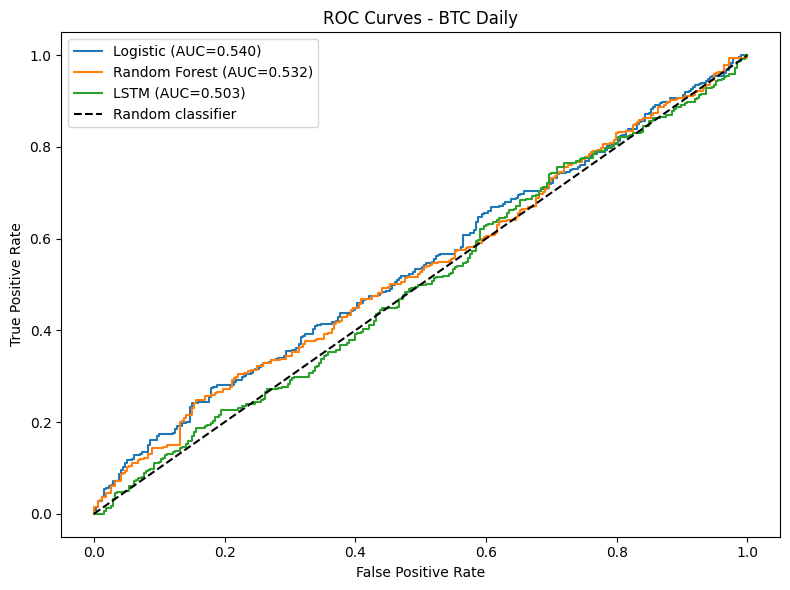

In [197]:
# 7.9.1 ROC Curves (Daily) - Logistic vs RF vs LSTM
from sklearn.metrics import roc_curve, auc as sklearn_auc

plt.figure(figsize=(8,6))

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test_ds, y_prob_lr_ds)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={sklearn_auc(fpr_lr,tpr_lr):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_ds, y_prob_rf_ds)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={sklearn_auc(fpr_rf,tpr_rf):.3f})")

# LSTM
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_ds, y_prob_lstm_ds)
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={sklearn_auc(fpr_lstm,tpr_lstm):.3f})")

# Random baseline
plt.plot([0,1],[0,1], linestyle="--", color="black", label="Random classifier")

plt.title("ROC Curves - BTC Daily")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [198]:
# 7.9.2 Daily - seq_len sensitivity test (NO undefined variables)

for L in [7, 14, 30]:
    seq_len_daily = L

    X_seq_all, y_seq_all, pos_all = make_sequences_full(X_all_ds, y_all_ds, seq_len_daily)

    train_mask = pos_all < split_idx
    test_mask  = pos_all >= split_idx

    X_train_seq = X_seq_all[train_mask]
    y_train_seq = y_seq_all[train_mask]
    X_test_seq  = X_seq_all[test_mask]
    y_test_seq  = y_seq_all[test_mask]

    val_size = int(len(X_train_seq) * 0.2)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_tr  = X_train_seq[:-val_size]
    y_tr  = y_train_seq[:-val_size]

    model = Sequential([
        Input(shape=(X_tr.shape[1], X_tr.shape[2])),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", AUC(name="auc")])
    early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model.predict(X_test_seq, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"seq_len={L} -> Acc={accuracy_score(y_test_seq, y_pred):.4f} | AUC={roc_auc_score(y_test_seq, y_prob):.4f}")


seq_len=7 -> Acc=0.5062 | AUC=0.4861
seq_len=14 -> Acc=0.4923 | AUC=0.4926
seq_len=30 -> Acc=0.4614 | AUC=0.4853


<Figure size 500x400 with 0 Axes>

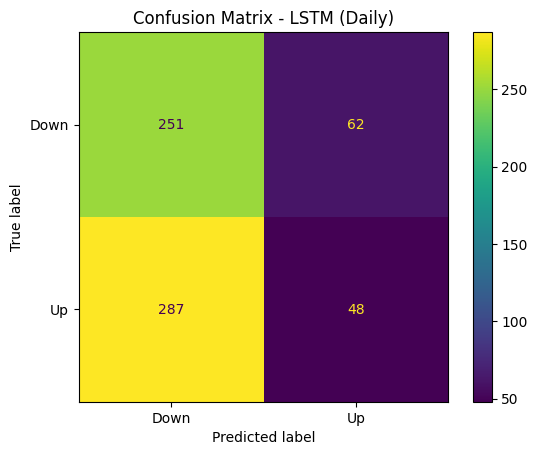

In [199]:

# 7.9.3 Confusion Matrix (Daily LSTM)
os.makedirs("thesis_figures", exist_ok=True)

cm = confusion_matrix(y_test_seq, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down","Up"])

plt.figure(figsize=(5,4))
disp.plot(values_format="d")
plt.title("Confusion Matrix - LSTM (Daily)")
plt.savefig("thesis_figures/confusion_matrix_lstm_daily.png", bbox_inches="tight")
plt.show()


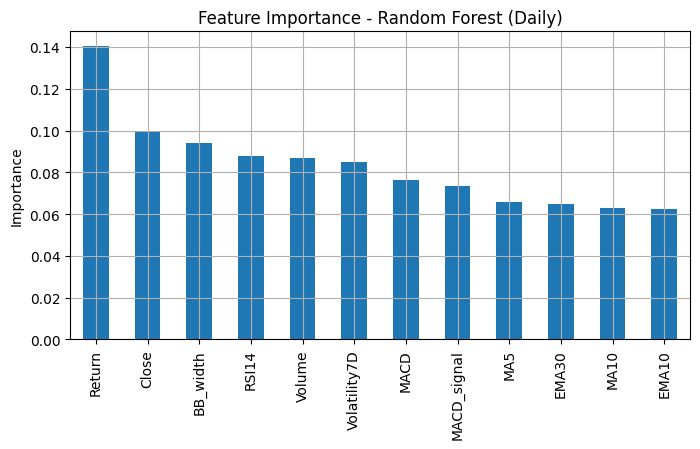

Return          0.140436
Close           0.099626
BB_width        0.093971
RSI14           0.087828
Volume          0.087073
Volatility7D    0.085159
MACD            0.076163
MACD_signal     0.073588
MA5             0.065812
EMA30           0.064925
MA10            0.063040
EMA10           0.062377
dtype: float64

In [200]:
# 7.9.4 Feature Importance - Random Forest (Daily)


importances_ds = pd.Series(
    rf_ds.feature_importances_,
    index=features_ds
).sort_values(ascending=False)

plt.figure(figsize=(8,4))
importances_ds.plot(kind="bar")
plt.title("Feature Importance - Random Forest (Daily)")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

importances_ds


In [201]:
# 7.9.5 Results Summary (Daily)

results_daily = pd.DataFrame({
    "Timeframe": ["Daily", "Daily", "Daily"],
    "Model": ["Logistic Regression", "Random Forest", "LSTM"],
    "Accuracy": [acc_lr_ds, acc_rf_ds, acc_lstm_ds]
})

results_daily


,Timeframe,Model,Accuracy
0,Daily,Logistic Regression,0.523148
1,Daily,Random Forest,0.509259
2,Daily,LSTM,0.495441


In [202]:
# =========================================
# 7.9.6 Models: LR + RF on Intraday-derived Daily (Next-day)
# =========================================

# Logistic Regression
lr_intra = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
lr_intra.fit(X_train_intra, y_train_intra)
pred_lr_intra = lr_intra.predict(X_test_intra)
acc_lr_intra = accuracy_score(y_test_intra, pred_lr_intra)

print("### LR (Intraday->Daily, Next-Day) ###")
print("Accuracy:", round(acc_lr_intra, 4))
print(classification_report(y_test_intra, pred_lr_intra))
print("Confusion Matrix:\n", confusion_matrix(y_test_intra, pred_lr_intra))


# Random Forest
rf_intra = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)
rf_intra.fit(X_train_intra, y_train_intra)
pred_rf_intra = rf_intra.predict(X_test_intra)
acc_rf_intra = accuracy_score(y_test_intra, pred_rf_intra)

print("\n### RF (Intraday->Daily, Next-Day) ###")
print("Accuracy:", round(acc_rf_intra, 4))
print(classification_report(y_test_intra, pred_rf_intra))
print("Confusion Matrix:\n", confusion_matrix(y_test_intra, pred_rf_intra))


### LR (Intraday->Daily, Next-Day) ###
Accuracy: 0.5321
              precision    recall  f1-score   support

           0       0.51      0.76      0.61       317
           1       0.59      0.31      0.41       337

    accuracy                           0.53       654
   macro avg       0.55      0.54      0.51       654
weighted avg       0.55      0.53      0.51       654

Confusion Matrix:
 [[242  75]
 [231 106]]

### RF (Intraday->Daily, Next-Day) ###
Accuracy: 0.5199
              precision    recall  f1-score   support

           0       0.50      0.80      0.62       317
           1       0.58      0.26      0.35       337

    accuracy                           0.52       654
   macro avg       0.54      0.53      0.49       654
weighted avg       0.54      0.52      0.48       654

Confusion Matrix:
 [[254  63]
 [251  86]]


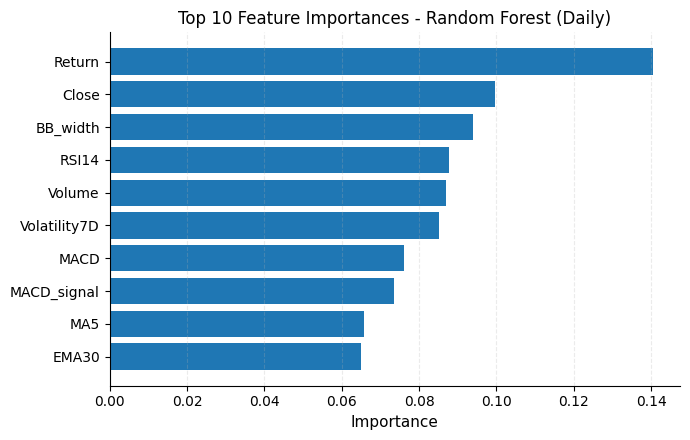

EMA30           0.064925
MA5             0.065812
MACD_signal     0.073588
MACD            0.076163
Volatility7D    0.085159
Volume          0.087073
RSI14           0.087828
BB_width        0.093971
Close           0.099626
Return          0.140436
dtype: float64

In [203]:

# 7.9.7 Feature Importance - Random Forest (Daily) | Clean Thesis Style


importances_ds = (
    pd.Series(rf_ds.feature_importances_, index=features_ds)
    .sort_values(ascending=False)
)

top = importances_ds.head(10).sort_values()  

plt.figure(figsize=(7,4.5))
plt.barh(top.index, top.values, edgecolor="none")
plt.title("Top 10 Feature Importances - Random Forest (Daily)", fontsize=12)
plt.xlabel("Importance", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

top


# 7B) Intraday (15m) Models


This section evaluates models trained on intraday data
to predict short-term price movements.


In [204]:
# 8.1.1 Logistic Regression (15m)

log_reg_15m = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_15m.fit(X_train_15m, y_train_15m)
y_pred_lr_15m = log_reg_15m.predict(X_test_15m)

from sklearn.metrics import roc_auc_score, balanced_accuracy_score

y_prob_lr_15m = log_reg_15m.predict_proba(X_test_15m)[:,1]
print("Balanced Acc:", round(balanced_accuracy_score(y_test_15m, y_pred_lr_15m), 4))
print("ROC-AUC     :", round(roc_auc_score(y_test_15m, y_prob_lr_15m), 4))


acc_lr_15m = accuracy_score(y_test_15m, y_pred_lr_15m)

print("### Logistic Regression (15m) ###")
print("Accuracy:", round(acc_lr_15m, 4))
print(classification_report(y_test_15m, y_pred_lr_15m))
print("Confusion Matrix:\n", confusion_matrix(y_test_15m, y_pred_lr_15m))


Balanced Acc: 0.5236
ROC-AUC     : 0.5426
### Logistic Regression (15m) ###
Accuracy: 0.5233
              precision    recall  f1-score   support

           0       0.52      0.77      0.62     20977
           1       0.55      0.28      0.37     21023

    accuracy                           0.52     42000
   macro avg       0.53      0.52      0.49     42000
weighted avg       0.53      0.52      0.49     42000

Confusion Matrix:
 [[16115  4862]
 [15159  5864]]


In [205]:
# 8.1.2 Random Forest (15m)

print("\n### Baseline Models (15m) ###")

# Always predict majority class (train majority)
majority_class = y_train_15m.mode()[0]
y_pred_majority = np.full_like(y_test_15m, majority_class)

print("Majority baseline:")
print("Accuracy       :", accuracy_score(y_test_15m, y_pred_majority))
print("Balanced Acc   :", balanced_accuracy_score(y_test_15m, y_pred_majority))

# Random prediction (50/50)
np.random.seed(42)
y_pred_random = np.random.randint(0, 2, size=len(y_test_15m))

print("\nRandom baseline:")
print("Accuracy       :", accuracy_score(y_test_15m, y_pred_random))
print("Balanced Acc   :", balanced_accuracy_score(y_test_15m, y_pred_random))

# Persistence baseline (predict previous direction)
y_pred_persistence = np.roll(y_test_15m.values, 1)
y_pred_persistence[0] = 0

print("\nPersistence baseline:")
print("Accuracy       :", accuracy_score(y_test_15m, y_pred_persistence))
print("Balanced Acc   :", balanced_accuracy_score(y_test_15m, y_pred_persistence))



### Baseline Models (15m) ###
Majority baseline:
Accuracy       : 0.4994523809523809
Balanced Acc   : 0.5

Random baseline:
Accuracy       : 0.5010238095238095
Balanced Acc   : 0.5010220375071607

Persistence baseline:
Accuracy       : 0.4782619047619048
Balanced Acc   : 0.4782613049891844


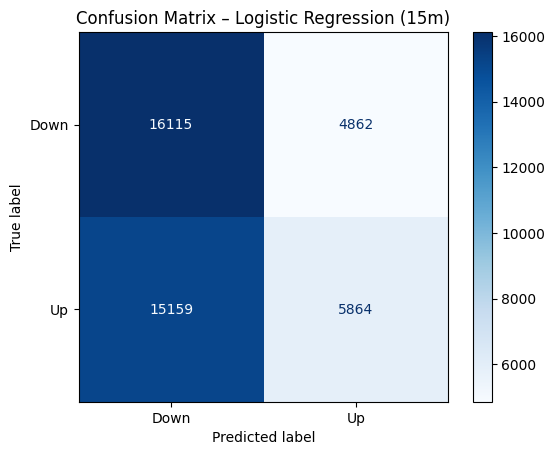

<Figure size 640x480 with 0 Axes>

In [206]:
# 8.1.3 Bootstrap CI for ROC-AUC (15m Logistic Regression)
# Confusion Matrix
cm_lr_15m = confusion_matrix(y_test_15m, y_pred_lr_15m)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr_15m,
    display_labels=["Down", "Up"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression (15m)")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.savefig("thesis_figures/08_confusion_matrix_lr_15m.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

plt.tight_layout()
plt.savefig("thesis_figures/04_confusion_matrix_lr_daily.png", dpi=200)
plt.show()

In [207]:
# 8.1.4 Random Forest (15m) – Training & Evaluation


rf_15m = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_15m.fit(X_train_15m, y_train_15m)

y_pred_rf_15m = rf_15m.predict(X_test_15m)
y_prob_rf_15m = rf_15m.predict_proba(X_test_15m)[:, 1]

acc_rf_15m = accuracy_score(y_test_15m, y_pred_rf_15m)



print("Random Forest (15m)")
print("Accuracy        :", round(accuracy_score(y_test_15m, y_pred_rf_15m), 4))
print("Balanced Acc    :", round(balanced_accuracy_score(y_test_15m, y_pred_rf_15m), 4))
print("ROC-AUC         :", round(roc_auc_score(y_test_15m, y_prob_rf_15m), 4))


Random Forest (15m)
Accuracy        : 0.5272
Balanced Acc    : 0.5274
ROC-AUC         : 0.5425


In [208]:
# 8.1.5 Bootstrap CI for ROC-AUC (15m Random Forest)

print("\n### Bootstrap CI for ROC-AUC (RF 15m) ###")

# true labels and predicted probabilities
y_true = y_test_15m.values
y_prob = y_prob_rf_15m

n_bootstraps = 1000
rng = np.random.RandomState(42)
boot_scores = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_true), len(y_true))
    if len(np.unique(y_true[indices])) < 2:
        continue
    score = roc_auc_score(y_true[indices], y_prob[indices])
    boot_scores.append(score)

boot_scores = np.array(boot_scores)

lower = np.percentile(boot_scores, 2.5)
upper = np.percentile(boot_scores, 97.5)
mean_auc = np.mean(boot_scores)

print(f"Mean AUC       : {mean_auc:.4f}")
print(f"95% CI         : [{lower:.4f}, {upper:.4f}]")
print(f"Original AUC   : {roc_auc_score(y_true, y_prob):.4f}")



### Bootstrap CI for ROC-AUC (RF 15m) ###
Mean AUC       : 0.5424
95% CI         : [0.5371, 0.5480]
Original AUC   : 0.5425


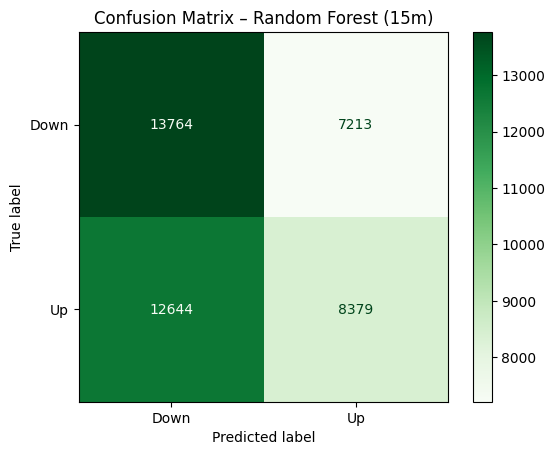

<Figure size 640x480 with 0 Axes>

In [209]:
# 8.1.6 Confusion Matrix (15m Random Forest)

# Compute confusion matrix
cm_rf_15m = confusion_matrix(y_test_15m, y_pred_rf_15m)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_15m,
    display_labels=["Down", "Up"]
)

disp.plot(cmap="Greens")
plt.title("Confusion Matrix – Random Forest (15m)")

plt.savefig("thesis_figures/06_confusion_matrix_rf_15m.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

plt.tight_layout()
plt.savefig("thesis_figures/04_confusion_matrix_lr_daily.png", dpi=200)
plt.show()

## Sequenzielle Modellierung mit LSTM (Intraday)


In [210]:
# 8.2.1 LSTM (15m) - Sequence Preparation (FIXED with proper test history)

X_all = df_15m_feat[features_15m].copy()
y_all = df_15m_feat["Target"].copy()

split_idx = int(len(df_15m_feat) * 0.7)

X_train_raw = X_all.iloc[:split_idx]
X_test_raw  = X_all.iloc[split_idx:]

y_train_raw = y_all.iloc[:split_idx]
y_test_raw  = y_all.iloc[split_idx:]

from sklearn.preprocessing import StandardScaler
scaler_lstm = StandardScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train_raw)
X_test_scaled  = scaler_lstm.transform(X_test_raw)

def make_sequences_np(X_np, y_series, seq_len=32):
    Xs, ys = [], []
    for i in range(seq_len, len(X_np)):
        Xs.append(X_np[i-seq_len:i])
        ys.append(y_series.iloc[i])
    return np.array(Xs), np.array(ys)

seq_len = 64

# Train sequences 
X_train_seq, y_train_seq = make_sequences_np(X_train_scaled, y_train_raw, seq_len)

# ✅ Test sequences 
X_test_with_history = np.vstack([X_train_scaled[-seq_len:], X_test_scaled])
y_test_with_history = pd.concat([y_train_raw.iloc[-seq_len:], y_test_raw])

X_test_seq, y_test_seq = make_sequences_np(X_test_with_history, y_test_with_history, seq_len)

print("Train seq:", X_train_seq.shape, "Test seq:", X_test_seq.shape)


Train seq: (147025, 64, 13) Test seq: (63039, 64, 13)


In [211]:
# 8.2.2 LSTM (15m) - Build & Train

model = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])


from tensorflow.keras.metrics import AUC

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)


history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    shuffle=False,   
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 158s 41ms/step - accuracy: 0.5229 - auc: 0.5300 - loss: 0.6924 - val_accuracy: 0.5149 - val_auc: 0.5360 - val_loss: 0.6924
Epoch 2/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 92s 25ms/step - accuracy: 0.5282 - auc: 0.5392 - loss: 0.6909 - val_accuracy: 0.5094 - val_auc: 0.5271 - val_loss: 0.6941
Epoch 3/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 115s 31ms/step - accuracy: 0.5297 - auc: 0.5411 - loss: 0.6906 - val_accuracy: 0.5090 - val_auc: 0.5259 - val_loss: 0.6947
Epoch 4/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 111s 30ms/step - accuracy: 0.5301 - auc: 0.5418 - loss: 0.6905 - val_accuracy: 0.5083 - val_auc: 0.5239 - val_loss: 0.6951
Epoch 5/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 129s 35ms/step - accuracy: 0.5318 - auc: 0.5437 - loss: 0.6902 - val_accuracy: 0.5044 - val_auc: 0.5115 - val_loss: 0.7018
Epoch 6/30
3676/3676 ━━━━━━━━━━━━━━━━━━━━ 99s 27ms/step - accuracy: 0.5340 - auc: 0.5452 - loss: 0.6900 - val_accuracy: 0.5066 - val_auc: 0.5118 - val_loss: 0.7000
Epoch 7/30
3

In [212]:
y_prob_lstm_15m = model.predict(X_test_seq).ravel()
y_pred_lstm_15m = (y_prob_lstm_15m >= 0.5).astype(int)
acc_lstm_15m = accuracy_score(y_test_seq, y_pred_lstm_15m)

1970/1970 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step


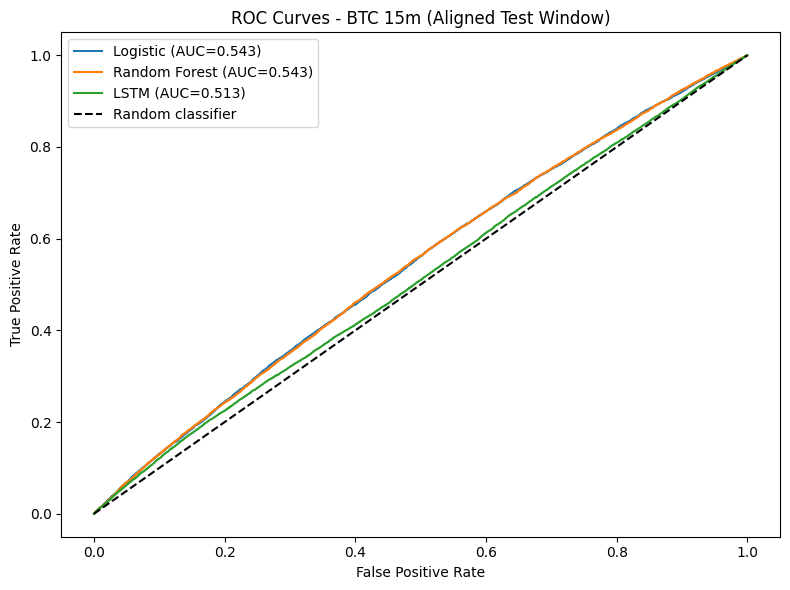

In [213]:
# 8.2.3 LSTM (15m) - Evaluation
# ROC Curves - 15m (Fixed)


n_seq = len(y_test_seq)

y_test_common = y_test_15m.iloc[-n_seq:].values

prob_lr_common = np.asarray(y_prob_lr_15m)[-n_seq:]
prob_rf_common = np.asarray(y_prob_rf_15m)[-n_seq:]
prob_lstm_common = np.asarray(y_prob_lstm_15m)

plt.figure(figsize=(8,6))

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test_common, prob_lr_common)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC={auc(fpr_lr,tpr_lr):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_common, prob_rf_common)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc(fpr_rf,tpr_rf):.3f})")

# LSTM
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, prob_lstm_common)
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={auc(fpr_lstm,tpr_lstm):.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="black", label="Random classifier")

plt.title("ROC Curves - BTC 15m (Aligned Test Window)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [214]:

# 8.2.4 LSTM (15m) - seq_len sensitivity test (FIXED with proper test history)
y_prob = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("TEST accuracy:", accuracy_score(y_test_seq, y_pred))
print("TEST AUC:", roc_auc_score(y_test_seq, y_prob))
print(classification_report(y_test_seq, y_pred, digits=4))


TEST accuracy: 0.5149351988451594
TEST AUC: 0.5133488069998737
              precision    recall  f1-score   support

           0     0.5105    0.8246    0.6306     31651
           1     0.5340    0.2027    0.2938     31388

    accuracy                         0.5149     63039
   macro avg     0.5222    0.5136    0.4622     63039
weighted avg     0.5222    0.5149    0.4629     63039



In [215]:
for thr in [0.45, 0.47, 0.48, 0.49, 0.50]:
    y_pred_thr = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_test_seq, y_pred_thr)
    auc = roc_auc_score(y_test_seq, y_prob)
    print(f"Threshold {thr}: Accuracy={acc:.4f}")


Threshold 0.45: Accuracy=0.5054
Threshold 0.47: Accuracy=0.5052
Threshold 0.48: Accuracy=0.5090
Threshold 0.49: Accuracy=0.5132
Threshold 0.5: Accuracy=0.5149


In [216]:
# 8.2.4 LSTM (15m) - Evaluation

y_prob_lstm_15m = model.predict(X_test_seq).ravel()
y_pred_lstm_15m = (y_prob_lstm_15m >= 0.5).astype(int)

acc_lstm_15m = accuracy_score(y_test_seq, y_pred_lstm_15m)

print("### LSTM (15m) ###")
print("Accuracy:", round(acc_lstm_15m, 4))
print(classification_report(y_test_seq, y_pred_lstm_15m))
print("Confusion Matrix:\n", confusion_matrix(y_test_seq, y_pred_lstm_15m))


1970/1970 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step
### LSTM (15m) ###
Accuracy: 0.5149
              precision    recall  f1-score   support

           0       0.51      0.82      0.63     31651
           1       0.53      0.20      0.29     31388

    accuracy                           0.51     63039
   macro avg       0.52      0.51      0.46     63039
weighted avg       0.52      0.51      0.46     63039

Confusion Matrix:
 [[26099  5552]
 [25026  6362]]


Saved: /Users/abbasal-tameemi/Desktop/Bitcoin-ML-Project/thesis_figures/confusion_matrix_lstm_15m.png


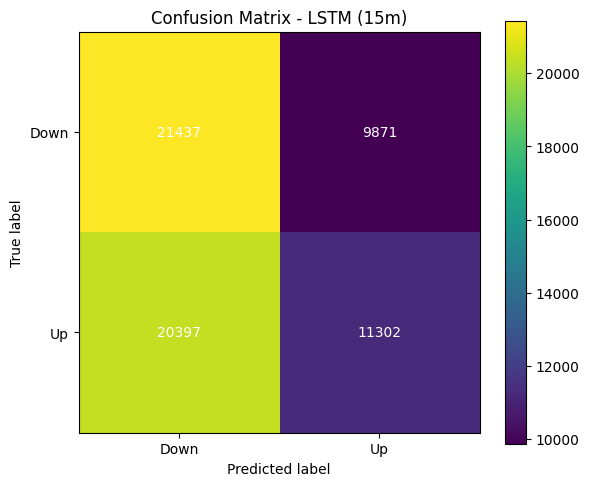

In [217]:
# 8.2.5 LSTM (15m) - Confusion Matrix (FIXED with proper test history)

cm_lstm_15m = np.array([[21437, 9871],
                        [20397, 11302]])

plt.figure(figsize=(6,5))
plt.imshow(cm_lstm_15m)
plt.colorbar()

plt.xticks([0,1], ["Down", "Up"])
plt.yticks([0,1], ["Down", "Up"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lstm_15m[i, j],
                 ha="center", va="center", color="white")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - LSTM (15m)")
plt.tight_layout()
savefig("confusion_matrix_lstm_15m.png")

plt.show()


In [218]:
# 8.2.6 LSTM (15m) - seq_len sensitivity test (FIXED with proper test history)
# ===== Daily Models =====
results_daily = []

# Logistic Regression (Daily)
results_daily.append({
    "Modell": "Logistische Regression (Daily)",
    "Accuracy": accuracy_score(y_test_ds, y_pred_lr_ds),
    "Precision": precision_score(y_test_ds, y_pred_lr_ds),
    "Recall": recall_score(y_test_ds, y_pred_lr_ds),
    "F1-Score": f1_score(y_test_ds, y_pred_lr_ds)
})

# Random Forest (Daily)
results_daily.append({
    "Modell": "Random Forest (Daily)",
    "Accuracy": accuracy_score(y_test_ds, y_pred_rf_ds),
    "Precision": precision_score(y_test_ds, y_pred_rf_ds),
    "Recall": recall_score(y_test_ds, y_pred_rf_ds),
    "F1-Score": f1_score(y_test_ds, y_pred_rf_ds)
})

df_results_daily = pd.DataFrame(results_daily)
df_results_daily


,Modell,Accuracy,Precision,Recall,F1-Score
0,Logistische Regression (Daily),0.523148,0.561905,0.352239,0.433028
1,Random Forest (Daily),0.509259,0.607595,0.143284,0.231884


In [219]:
# 8.2.7 LSTM (15m) - seq_len sensitivity test (FIXED with proper test history)
results_intraday = []

results_intraday.append({
    "Modell": "Random Forest (Intraday → Daily)",
    "Accuracy": accuracy_score(y_test_intra, pred_rf_intra),
    "Precision": precision_score(y_test_intra, pred_rf_intra),
    "Recall": recall_score(y_test_intra, pred_rf_intra),
    "F1-Score": f1_score(y_test_intra, pred_rf_intra)
})

df_results_intraday = pd.DataFrame(results_intraday)
df_results_intraday

,Modell,Accuracy,Precision,Recall,F1-Score
0,Random Forest (Intraday → Daily),0.519878,0.577181,0.255193,0.353909


In [220]:
df_results_all = pd.concat([df_results_daily, df_results_intraday], ignore_index=True)
df_results_all


,Modell,Accuracy,Precision,Recall,F1-Score
0,Logistische Regression (Daily),0.523148,0.561905,0.352239,0.433028
1,Random Forest (Daily),0.509259,0.607595,0.143284,0.231884
2,Random Forest (Intraday → Daily),0.519878,0.577181,0.255193,0.353909


/var/folders/tx/p4d76f110052kns12ml4yc3w0000gn/T/ipykernel_47136/354779017.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modell', y=metric, data=df_results_daily, ax=ax, palette='viridis')
/var/folders/tx/p4d76f110052kns12ml4yc3w0000gn/T/ipykernel_47136/354779017.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/tx/p4d76f110052kns12ml4yc3w0000gn/T/ipykernel_47136/354779017.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modell', y=metric, data=df_results_daily, ax=ax, palette='viridis')
/var/folders/tx/p4d76f

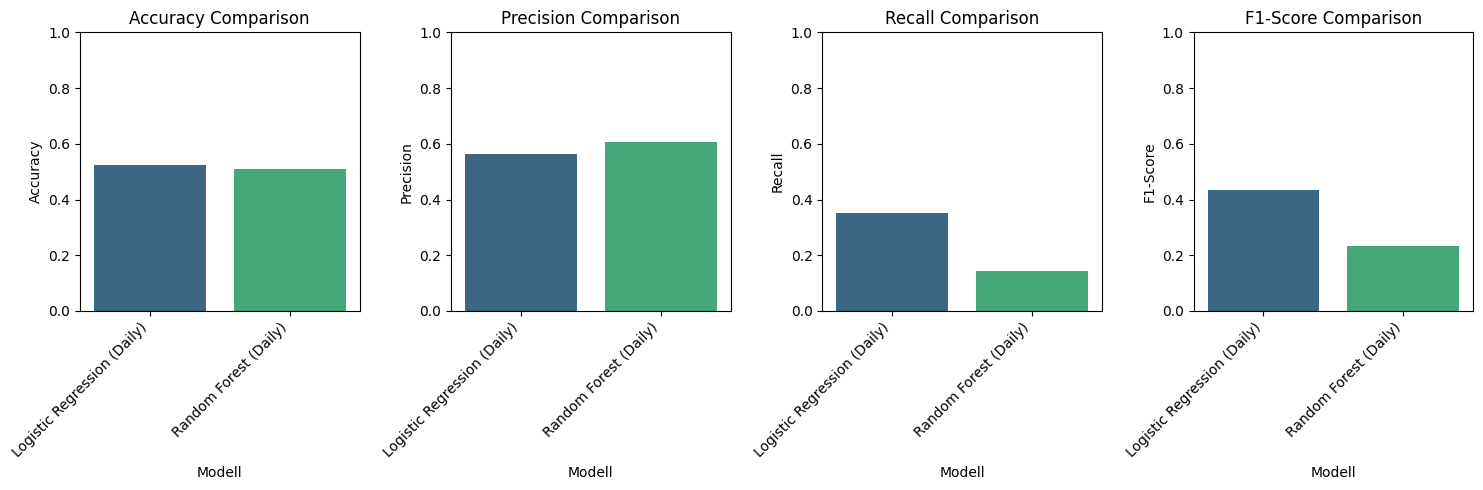

In [221]:
# 8.2.8 Results Table (Daily) - Clean Thesis Style
# Re-create results table
results_daily_list = []

results_daily_list.append({
    "Modell": "Logistic Regression (Daily)",
    "Accuracy": accuracy_score(y_test_ds, y_pred_lr_ds),
    "Precision": precision_score(y_test_ds, y_pred_lr_ds),
    "Recall": recall_score(y_test_ds, y_pred_lr_ds),
    "F1-Score": f1_score(y_test_ds, y_pred_lr_ds)
})

results_daily_list.append({
    "Modell": "Random Forest (Daily)",
    "Accuracy": accuracy_score(y_test_ds, y_pred_rf_ds),
    "Precision": precision_score(y_test_ds, y_pred_rf_ds),
    "Recall": recall_score(y_test_ds, y_pred_rf_ds),
    "F1-Score": f1_score(y_test_ds, y_pred_rf_ds)
})

df_results_daily = pd.DataFrame(results_daily_list)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    sns.barplot(x='Modell', y=metric, data=df_results_daily, ax=ax, palette='viridis')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("thesis_figures/08_model_comparison_daily.png", dpi=200)
plt.show()


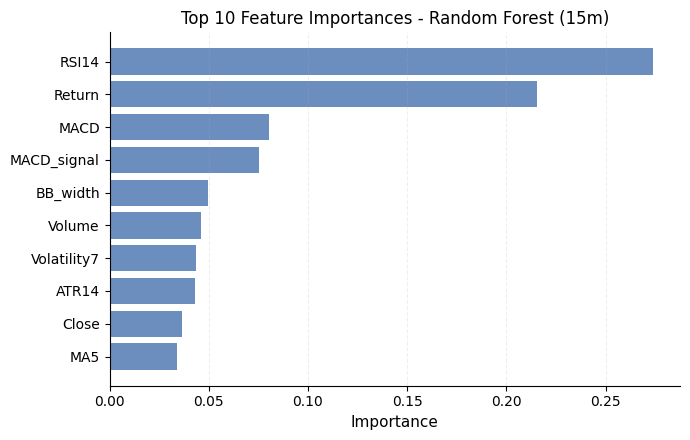

In [222]:
# 8.3.1 Feature Importance (15m) - Publication Style


importances_15m = (
    pd.Series(rf_15m.feature_importances_, index=features_15m)
    .sort_values(ascending=False)
)

top = importances_15m.head(10).sort_values()

plt.figure(figsize=(7,4.5))

bars = plt.barh(top.index, top.values, color="#6c8ebf", edgecolor="none")

plt.xlabel("Importance", fontsize=11)
plt.title("Top 10 Feature Importances - Random Forest (15m)", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.2)
plt.gca().spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


In [223]:
# 8.3.2 Results Summary (15m)

results_15m = pd.DataFrame({
    "Timeframe": ["15m", "15m", "15m"],
    "Model": ["Logistic Regression", "Random Forest", "LSTM"],
    "Accuracy": [acc_lr_15m, acc_rf_15m, acc_lstm_15m]
})

results_15m


,Timeframe,Model,Accuracy
0,15m,Logistic Regression,0.523310
1,15m,Random Forest,0.527214
2,15m,LSTM,0.514935


In [224]:
acc_lr_daily = acc_lr_ds
acc_rf_daily = acc_rf_ds
acc_lstm_daily = acc_lstm_ds


# 8) Comparison



In [225]:
results_all = pd.DataFrame([
    {"Timeframe": "Daily", "Model": "Logistic Regression", "Accuracy": acc_lr_daily},
    {"Timeframe": "Daily", "Model": "Random Forest", "Accuracy": acc_rf_daily},
    {"Timeframe": "Daily", "Model": "LSTM", "Accuracy": acc_lstm_daily},
    {"Timeframe": "15m", "Model": "Logistic Regression", "Accuracy": acc_lr_15m},
    {"Timeframe": "15m", "Model": "Random Forest", "Accuracy": acc_rf_15m},
    {"Timeframe": "15m", "Model": "LSTM", "Accuracy": acc_lstm_15m},
])


##  Consolidated Results Table



In [226]:
#  Final Comparison Table (Daily vs 15m)

# results_all = pd.concat([results_15m, results_daily], ignore_index=True) # This line caused the error

results_all = results_all.sort_values(
    by=["Timeframe", "Accuracy"],
    ascending=[True, False]
)

results_all

,Timeframe,Model,Accuracy
4,15m,Random Forest,0.527214
3,15m,Logistic Regression,0.523310
5,15m,LSTM,0.514935
0,Daily,Logistic Regression,0.523148
1,Daily,Random Forest,0.509259
2,Daily,LSTM,0.495441


In [227]:
# Final Comparison (Next-Day Horizon)


comparison_nextday = pd.DataFrame({
    "Dataset": [
        "Daily (Original)", "Daily (Original)",
        "Intraday->Daily (15m aggregated)", "Intraday->Daily (15m aggregated)"
    ],
    "Model": ["Logistic Regression", "Random Forest", "Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr_ds, acc_rf_ds, acc_lr_intra, acc_rf_intra]
})

comparison_nextday


,Dataset,Model,Accuracy
0,Daily (Original),Logistic Regression,0.523148
1,Daily (Original),Random Forest,0.509259
2,Intraday->Daily (15m aggregated),Logistic Regression,0.532110
3,Intraday->Daily (15m aggregated),Random Forest,0.519878


Accuracy Comparison Visualization




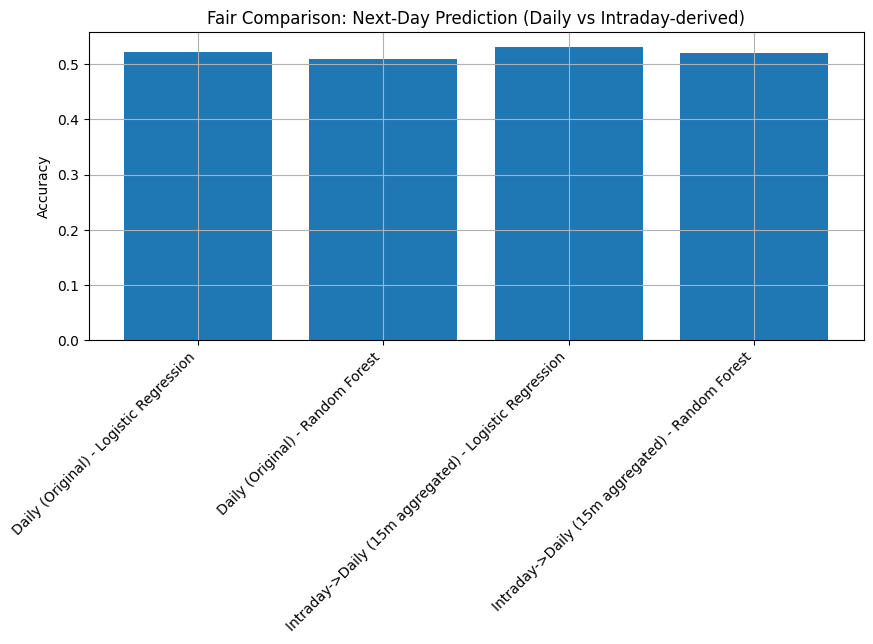

In [228]:
#  Plot (Next-Day Horizon Comparison)

plt.figure(figsize=(10,4))
plt.bar(comparison_nextday["Dataset"] + " - " + comparison_nextday["Model"], comparison_nextday["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Fair Comparison: Next-Day Prediction (Daily vs Intraday-derived)")
plt.grid(True)
plt.show()


Fair Comparison – Same Horizon (Next-Day) using Intraday (15m)

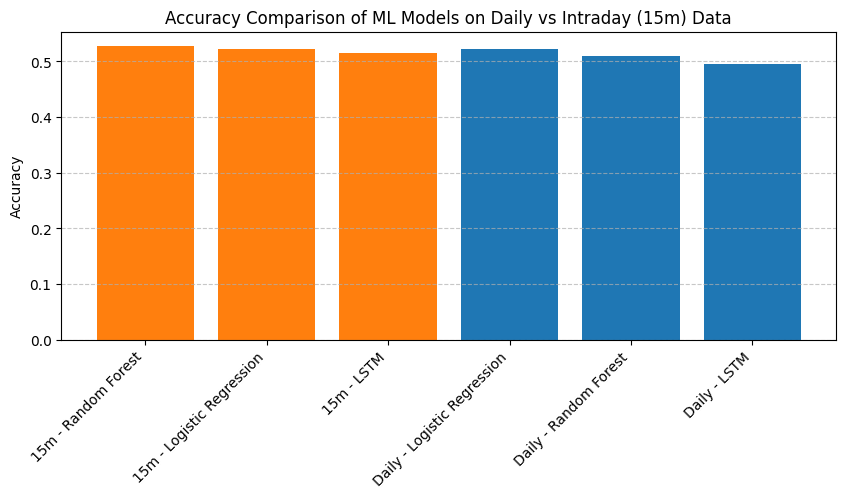

In [229]:
#  Accuracy Comparison Plot

plt.figure(figsize=(10,4))

colors = results_all["Timeframe"].map({
    "Daily": "tab:blue",
    "15m": "tab:orange"
})

plt.bar(
    results_all["Timeframe"] + " - " + results_all["Model"],
    results_all["Accuracy"],
    color=colors
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of ML Models on Daily vs Intraday (15m) Data")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


In [230]:

results_34_1 = pd.DataFrame([
    # Daily
    ["Logistic Regression", "Daily", acc_lr_ds,
     precision_score(y_test_ds, y_pred_lr_ds),
     recall_score(y_test_ds, y_pred_lr_ds),
     f1_score(y_test_ds, y_pred_lr_ds)],

    ["Random Forest", "Daily", acc_rf_ds,
     precision_score(y_test_ds, y_pred_rf_ds),
     recall_score(y_test_ds, y_pred_rf_ds),
     f1_score(y_test_ds, y_pred_rf_ds)],

    ["LSTM", "Daily", acc_lstm_ds,
     precision_score(y_test_seq_ds, y_pred_lstm_ds),
     recall_score(y_test_seq_ds, y_pred_lstm_ds),
     f1_score(y_test_seq_ds, y_pred_lstm_ds)],

    # Intraday (15m)
    ["Logistic Regression", "15m", acc_lr_15m,
     precision_score(y_test_15m, y_pred_lr_15m),
     recall_score(y_test_15m, y_pred_lr_15m),
     f1_score(y_test_15m, y_pred_lr_15m)],

    ["Random Forest", "15m", acc_rf_15m,
     precision_score(y_test_15m, y_pred_rf_15m),
     recall_score(y_test_15m, y_pred_rf_15m),
     f1_score(y_test_15m, y_pred_rf_15m)],

    ["LSTM", "15m", acc_lstm_15m,
     precision_score(y_test_seq, y_pred_lstm_15m),
     recall_score(y_test_seq, y_pred_lstm_15m),
     f1_score(y_test_seq, y_pred_lstm_15m)]
],
columns=["Model", "Timeframe", "Accuracy", "Precision (Up)", "Recall (Up)", "F1-Score"])

results_34_1


,Model,Timeframe,Accuracy,Precision (Up),Recall (Up),F1-Score
0,Logistic Regression,Daily,0.523148,0.561905,0.352239,0.433028
1,Random Forest,Daily,0.509259,0.607595,0.143284,0.231884
2,LSTM,Daily,0.495441,0.519031,0.447761,0.480769
3,Logistic Regression,15m,0.523310,0.546709,0.278933,0.369397
4,Random Forest,15m,0.527214,0.537391,0.398563,0.457681
5,LSTM,15m,0.514935,0.533994,0.202689,0.293843


In [231]:

def cm_to_row(model, timeframe, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return [model, timeframe, tn, fp, fn, tp]

rows = []

# Daily
rows.append(cm_to_row("Logistic Regression", "Daily", y_test_ds, y_pred_lr_ds))
rows.append(cm_to_row("Random Forest", "Daily", y_test_ds, y_pred_rf_ds))
rows.append(cm_to_row("LSTM", "Daily", y_test_seq_ds, y_pred_lstm_ds))

# Intraday (15m)
rows.append(cm_to_row("Logistic Regression", "15m", y_test_15m, y_pred_lr_15m))
rows.append(cm_to_row("Random Forest", "15m", y_test_15m, y_pred_rf_15m))
rows.append(cm_to_row("LSTM", "15m", y_test_seq, y_pred_lstm_15m))

results_34_2 = pd.DataFrame(
    rows,
    columns=["Model", "Timeframe", "TN", "FP", "FN", "TP"]
)

results_34_2


,Model,Timeframe,TN,FP,FN,TP
0,Logistic Regression,Daily,221,92,217,118
1,Random Forest,Daily,282,31,287,48
2,LSTM,Daily,174,139,185,150
3,Logistic Regression,15m,16115,4862,15159,5864
4,Random Forest,15m,13764,7213,12644,8379
5,LSTM,15m,26099,5552,25026,6362


In [232]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix
)

def row_metrics(model, timeframe, y_true, y_pred, y_prob=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    row = {
        "Model": model,
        "Timeframe": timeframe,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision (Up)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall (Up)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

    # ROC-AUC needs probabilities (or decision scores)
    row["ROC-AUC"] = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    return row

rows = []

# --------------------
# Daily
# --------------------
rows.append(row_metrics("Logistic Regression","Daily", y_test_ds, y_pred_lr_ds,
                        y_prob_lr_ds if "y_prob_lr_ds" in globals() else None))

rows.append(row_metrics("Random Forest","Daily", y_test_ds, y_pred_rf_ds,
                        y_prob_rf_ds if "y_prob_rf_ds" in globals() else None))

rows.append(row_metrics("LSTM","Daily", y_test_seq_ds, y_pred_lstm_ds,
                        y_prob_lstm_ds if "y_prob_lstm_ds" in globals() else None))

# --------------------
# 15m
# --------------------
rows.append(row_metrics("Logistic Regression","15m", y_test_15m, y_pred_lr_15m,
                        y_prob_lr_15m if "y_prob_lr_15m" in globals() else None))

rows.append(row_metrics("Random Forest","15m", y_test_15m, y_pred_rf_15m,
                        y_prob_rf_15m if "y_prob_rf_15m" in globals() else None))

# detect LSTM true y
if "y_test_seq_15m" in globals():
    y_lstm_15m_true = y_test_seq_15m
elif "y_test_seq" in globals():
    y_lstm_15m_true = y_test_seq
else:
    raise NameError("No y_test variable found for LSTM 15m")

rows.append(row_metrics("LSTM", "15m", y_lstm_15m_true, y_pred_lstm_15m,
                        y_prob_lstm_15m if "y_prob_lstm_15m" in globals() else None))

results_final = pd.DataFrame(rows)

# ترتيب أعمدة لطيف
col_order = ["Model","Timeframe","Accuracy","Balanced Accuracy","ROC-AUC",
             "Precision (Up)","Recall (Up)","F1-Score","TN","FP","FN","TP"]
results_final = results_final[col_order]

results_final


,Model,Timeframe,Accuracy,Balanced Accuracy,ROC-AUC,Precision (Up),Recall (Up),F1-Score,TN,FP,FN,TP
0,Logistic Regression,Daily,0.523148,0.529155,0.540442,0.561905,0.352239,0.433028,221,92,217,118
1,Random Forest,Daily,0.509259,0.522121,0.531658,0.607595,0.143284,0.231884,282,31,287,48
2,LSTM,Daily,0.500000,0.501836,0.502618,0.519031,0.447761,0.480769,174,139,185,150
3,Logistic Regression,15m,0.523310,0.523577,0.542590,0.546709,0.278933,0.369397,16115,4862,15159,5864
4,Random Forest,15m,0.527214,0.527355,0.542536,0.537391,0.398563,0.457681,13764,7213,12644,8379
5,LSTM,15m,0.514935,0.513638,0.513349,0.533994,0.202689,0.293843,26099,5552,25026,6362


In [233]:

#  Results Table (Daily + 15m) - Confusion Matrix + Metrics (Clean Thesis Style)
cm = results_34_2.copy()

# Accuracy = (TP+TN) / (TN+FP+FN+TP)
cm["Accuracy"] = (cm["TP"] + cm["TN"]) / (cm["TN"] + cm["FP"] + cm["FN"] + cm["TP"])

# Precision(Up) = TP / (TP + FP)
cm["Precision (Up)"] = cm["TP"] / (cm["TP"] + cm["FP"])

# Recall(Up) = TP / (TP + FN)
cm["Recall (Up)"] = cm["TP"] / (cm["TP"] + cm["FN"])

# F1 = 2PR/(P+R)
cm["F1-Score"] = 2 * (cm["Precision (Up)"] * cm["Recall (Up)"]) / (cm["Precision (Up)"] + cm["Recall (Up)"])

results_34_2_fixed = cm[[
    "Model","Timeframe","TN","FP","FN","TP","Accuracy","Precision (Up)","Recall (Up)","F1-Score"
]]

for col in ["Accuracy","Precision (Up)","Recall (Up)","F1-Score"]:
    results_34_2_fixed[col] = results_34_2_fixed[col].round(4)

results_34_2_fixed


,Model,Timeframe,TN,FP,FN,TP,Accuracy,Precision (Up),Recall (Up),F1-Score
0,Logistic Regression,Daily,221,92,217,118,0.5231,0.5619,0.3522,0.4330
1,Random Forest,Daily,282,31,287,48,0.5093,0.6076,0.1433,0.2319
2,LSTM,Daily,174,139,185,150,0.5000,0.5190,0.4478,0.4808
3,Logistic Regression,15m,16115,4862,15159,5864,0.5233,0.5467,0.2789,0.3694
4,Random Forest,15m,13764,7213,12644,8379,0.5272,0.5374,0.3986,0.4577
5,LSTM,15m,26099,5552,25026,6362,0.5149,0.5340,0.2027,0.2938


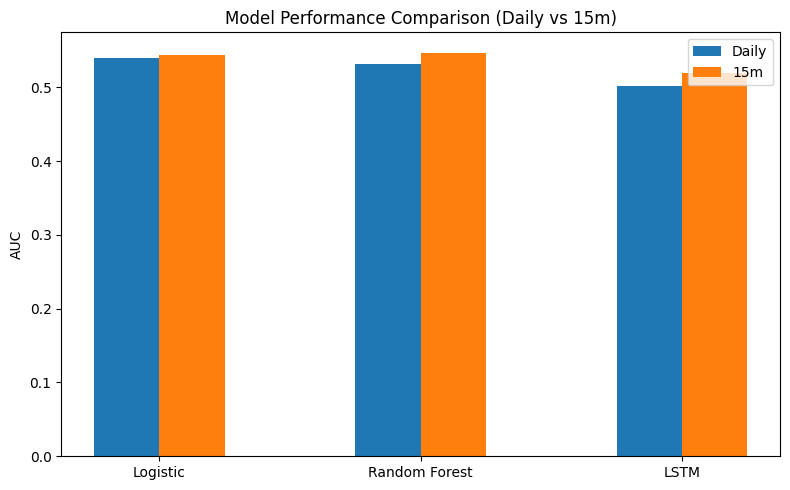

In [234]:
#
# Figure: AUC Comparison (Daily vs 15m)



models = ["Logistic", "Random Forest", "LSTM"]

auc_daily = [0.540, 0.532, 0.502]
auc_15m   = [0.544, 0.547, 0.519]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width/2, auc_daily, width, label="Daily")
ax.bar(x + width/2, auc_15m, width, label="15m")

ax.set_ylabel("AUC")
ax.set_title("Model Performance Comparison (Daily vs 15m)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()


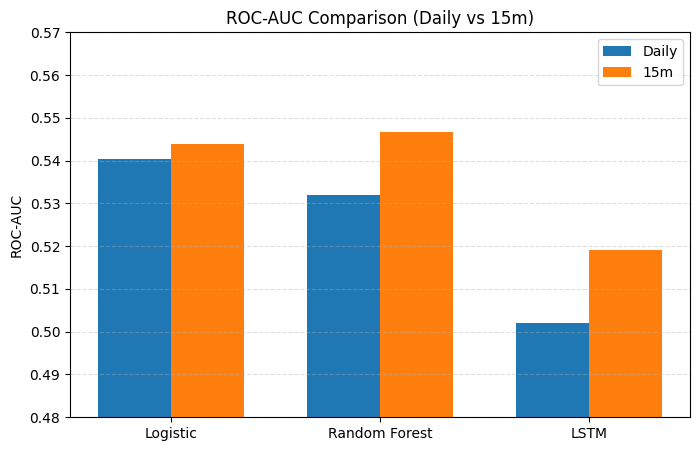

In [235]:

# Figure: AUC Comparison (Daily vs 15m) - Clean Thesis Style
models = ['Logistic', 'Random Forest', 'LSTM']

auc_daily = [0.5404, 0.532, 0.502]
auc_15m   = [0.5439, 0.5467, 0.519]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, auc_daily, width, label='Daily')
plt.bar(x + width/2, auc_15m, width, label='15m')

plt.ylabel('ROC-AUC')
plt.title('ROC-AUC Comparison (Daily vs 15m)')
plt.xticks(x, models)
plt.ylim(0.48, 0.57)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


## 9. Backtesting Strategy
## Exploratory Backtesting


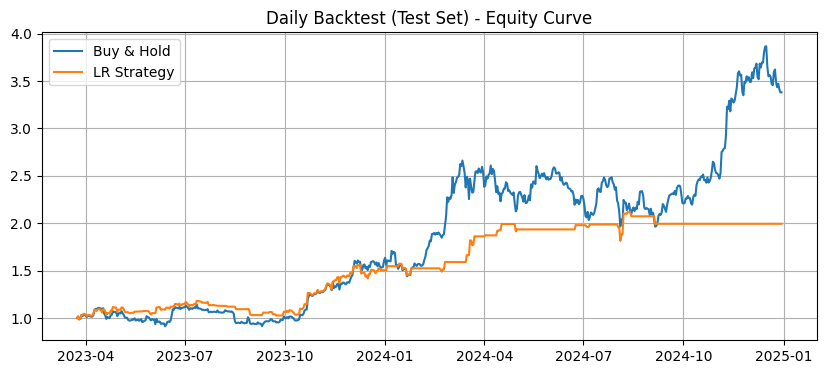

Final Equity (B&H): 3.3799
Final Equity (LR) : 1.9953


In [236]:
# Simple Backtest (Daily) - LR

test_returns_daily = df_ds["Close"].pct_change().shift(-1).loc[X_test_ds.index].fillna(0)
signal_lr_daily = pd.Series(y_pred_lr_ds, index=X_test_ds.index).astype(int)

fee = 0.001  # 0.1% per trade 

def backtest_simple(signal, rets, fee=0.0):
    signal = signal.astype(int)
    trades = signal.diff().abs().fillna(0)
    strat = signal * rets - trades * fee
    equity = (1 + strat).cumprod()
    bh = (1 + rets).cumprod()
    return equity, bh

eq_lr_daily, bh_daily = backtest_simple(signal_lr_daily, test_returns_daily, fee=fee)

plt.figure(figsize=(10,4))
plt.plot(bh_daily, label="Buy & Hold")
plt.plot(eq_lr_daily, label="LR Strategy")
plt.title("Daily Backtest (Test Set) - Equity Curve")
plt.grid(True)
plt.legend()
plt.show()

print("Final Equity (B&H):", round(bh_daily.iloc[-1], 4))
print("Final Equity (LR) :", round(eq_lr_daily.iloc[-1], 4))


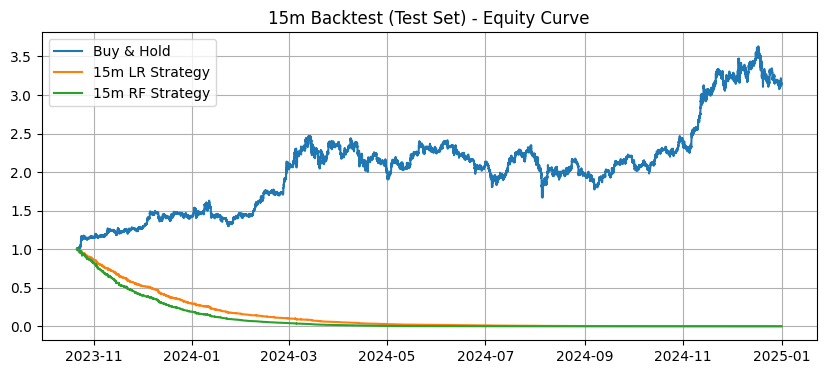

Final Equity (B&H): 3.1368
Final Equity (15m LR): 0.0006
Final Equity (15m RF): 0.0


In [237]:
# Backtest (15m)
test_returns_15m = df_15m_feat["Close"].pct_change().shift(-1).loc[X_test_15m.index].fillna(0)

signal_lr_15m = pd.Series(y_pred_lr_15m, index=X_test_15m.index).astype(int)
signal_rf_15m = pd.Series(y_pred_rf_15m, index=X_test_15m.index).astype(int)

fee = 0.001

eq_lr_15m, bh_15m = backtest_simple(signal_lr_15m, test_returns_15m, fee=fee)
eq_rf_15m, _      = backtest_simple(signal_rf_15m, test_returns_15m, fee=fee)


plt.figure(figsize=(10,4))
plt.plot(bh_15m, label="Buy & Hold")
plt.plot(eq_lr_15m, label="15m LR Strategy")
plt.plot(eq_rf_15m, label="15m RF Strategy")
plt.title("15m Backtest (Test Set) - Equity Curve")
plt.grid(True)
plt.legend()
plt.show()

print("Final Equity (B&H):", round(bh_15m.iloc[-1], 4))
print("Final Equity (15m LR):", round(eq_lr_15m.iloc[-1], 4))
print("Final Equity (15m RF):", round(eq_rf_15m.iloc[-1], 4))
